

<a href="https://colab.research.google.com/github/alura-es-cursos/Inmersion-en-Datos-con-Python/blob/aula02/credito_banco_aleman_inmersion_Dia2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

---
Diego Alejandro Quintero Andrade

---

#🧹 1. Limpieza y preparación de datos

📌 Dataset principal: movies_metadata.csv

**Tareas:**

- Identificar columnas con valores nulos.

**Convertir:**

- release_date → tipo fecha

- budget y revenue → numéricos

**Eliminar películas:**

- Sin presupuesto o sin ingresos

- Con valores claramente erróneos (budget = 0)

- Detectar y eliminar duplicados.


**🎯 Objetivo: dejar un dataset limpio y confiable.**

In [ ]:
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

# mostrar todas las columnas del dataset
pd.set_option('display.max_columns', None)

In [ ]:
df_movies = pd.read_csv('movies_metadata.csv')
movies = df_movies.copy()
movies.sample(3)

/tmp/ipykernel_2487/4208506337.py:1: DtypeWarning: Columns (10) have mixed types. Specify dtype option on import or set low_memory=False.
  df_movies = pd.read_csv('movies_metadata.csv')


,adult,belongs_to_collection,budget,genres,homepage,id,imdb_id,original_language,original_title,overview,popularity,poster_path,production_companies,production_countries,release_date,revenue,runtime,spoken_languages,status,tagline,title,video,vote_average,vote_count
40591,False,NaN,0,"[{'id': 10751, 'name': 'Family'}]",NaN,63809,tt0301935,en,Three Days,"Ten years ago, Andrew married his childhood sw...",0.429065,/n3RmSJTr6L4jHwU90p5x3nxjW43.jpg,[],"[{'iso_3166_1': 'US', 'name': 'United States o...",2001-12-09,0.0,91.0,"[{'iso_639_1': 'en', 'name': 'English'}]",Released,An angel interrupts destiny to give love 72 ho...,Three Days,False,5.9,4.0
21930,False,NaN,0,"[{'id': 10402, 'name': 'Music'}]",NaN,256396,tt0039032,en,The Thrill of Brazil,"Steve, revue producer in Rio de Janeiro, is st...",0.917732,/yWok2tQr8qXHfvDD59exQg4aOFT.jpg,"[{'name': 'Columbia Pictures Corporation', 'id...","[{'iso_3166_1': 'US', 'name': 'United States o...",1946-09-06,0.0,91.0,"[{'iso_639_1': 'en', 'name': 'English'}]",Released,Romantic Rio on a heart-to-heart hook-up wit m...,The Thrill of Brazil,False,7.0,2.0
29443,False,NaN,8000000,[],NaN,266331,tt0086405,en,Table For Five,J.P. Tannen (Jon Voight) wants a second chance...,0.406505,/ot8TP3Cv5mFR5Q5LfAXQELekRik.jpg,[],[],1983-02-18,2439705.0,121.0,"[{'iso_639_1': 'en', 'name': 'English'}]",Released,He just wants a second chance to love his chil...,Table For Five,False,4.8,3.0


## Identificar columnas con valores nulos

Antes de tratar los datos nulos, identificamos columnas con datos mixtos (listas de diccionarios). Procederemos a normalizar primero estos datos.

Las columnas son:

- belongs_to_collection

- genres

- production_companies

- production_countries

- spoken_languages

In [ ]:
import ast

def normalizar_lista_diccionarios(df: pd.DataFrame, col: str, prefix: str = None) -> pd.DataFrame:
    """
    Normaliza una columna que puede contener diccionarios simples o listas de diccionarios
    (en formato string o dict). Detecta automáticamente el tipo de contenido para
    aplicar 'explode' solo cuando es necesario.

    Parámetros:
    -----------
    df     : pd.DataFrame -> DataFrame original.
    col    : str          -> Nombre de la columna a normalizar.
    prefix : str, opcional -> Prefijo para las nuevas columnas. Si es None, usa el nombre de 'col'.

    Retorna:
    --------
    pd.DataFrame -> DataFrame actualizado con la columna original expandida en nuevas columnas.
    """

    # Configuración de prefijo inicial
    if prefix is None:
        prefix = col

    def safe_eval(x):
        """Convierte strings a objetos Python y estandariza nulos."""
        if pd.isna(x) or x == "" or x == "[]" or x == "{}":
            return None
        if isinstance(x, str):
            try:
                # Intenta convertir el string a objeto de Python (list o dict)
                return ast.literal_eval(x)
            except (ValueError, SyntaxError):
                return None
        return x

    # Limpieza inicial: Convertir strings a objetos reales
    # Trabajamos sobre una copia para no alterar el DataFrame original accidentalmente hasta el final
    df_temp = df.copy()
    df_temp[col] = df_temp[col].apply(safe_eval)

    # Identificación de estructura
    # Buscamos el primer valor que no sea nulo para saber si es una lista o un dict
    valores_no_nulos = df_temp[col].dropna()
    primer_valor = valores_no_nulos.iloc[0] if not valores_no_nulos.empty else None

    # Aplicación de Explode (Solo si es una lista)
    # Si detectamos una lista, expandimos el DataFrame hacia abajo (nuevas filas)
    if isinstance(primer_valor, list):
        df_temp = df_temp.explode(col, ignore_index=True)

    # Preparación para Normalización
    # Aseguramos que cada celda sea un diccionario (aunque esté vacío) para evitar errores
    df_temp[col] = df_temp[col].apply(lambda x: x if isinstance(x, dict) else {})

    # Expansión a columnas (json_normalize)
    # Crea un DataFrame donde cada llave del diccionario es una columna
    normalizado = pd.json_normalize(df_temp[col]).add_prefix(f"{prefix}_")

    # Unión final
    # Eliminamos la columna original procesada y concatenamos las nuevas columnas planas
    df_final = pd.concat([df_temp.drop(columns=[col]), normalizado], axis=1)

    return df_final

In [ ]:
normalizado_movies = normalizar_lista_diccionarios(movies, 'belongs_to_collection')

In [ ]:
normalizado_movies = normalizar_lista_diccionarios(normalizado_movies, 'genres')

In [ ]:
normalizado_movies = normalizar_lista_diccionarios(normalizado_movies, 'production_companies')

In [ ]:
normalizado_movies = normalizar_lista_diccionarios(normalizado_movies, 'production_countries')

In [ ]:
normalizado_movies = normalizar_lista_diccionarios(normalizado_movies, 'spoken_languages')

In [ ]:
normalizado_movies.sample(3)

,adult,budget,homepage,id,imdb_id,original_language,original_title,overview,popularity,poster_path,release_date,revenue,runtime,status,tagline,title,video,vote_average,vote_count,belongs_to_collection_id,belongs_to_collection_name,belongs_to_collection_poster_path,belongs_to_collection_backdrop_path,genres_id,genres_name,production_companies_name,production_companies_id,production_countries_iso_3166_1,production_countries_name,spoken_languages_iso_639_1,spoken_languages_name
59484,False,0,NaN,108267,tt0051876,en,The Lone Ranger and the Lost City of Gold,Three Indians were brutally murdered by a gang...,1.037915,/5MD2vYaIJmMni2isU51ue1l5oAS.jpg,1958-01-01,0.0,81.0,Released,NaN,The Lone Ranger and the Lost City of Gold,False,6.3,3.0,460292.0,The Lone Ranger (Clayton Moore) Collection,None,None,28.0,Action,Wrather Productions,10593.0,US,United States of America,en,English
278504,False,2000000,http://www.visionsofeurope.dk/,8985,tt0425624,en,Visions of Europe,Twenty-five films from twenty-five European co...,0.958683,/wnqFO3tyBNAQD7E7Xd2IhcgQ5mu.jpg,2004-05-01,0.0,140.0,Released,NaN,Visions of Europe,False,3.7,3.0,NaN,NaN,NaN,NaN,18.0,Drama,TT Filmműhely,55461.0,IT,Italy,fr,Français
254369,False,0,NaN,21381,tt0098157,en,Les mémés cannibales,A large family gathers in the country side for...,0.003553,/eWNhyY6AECUvA0mROwZI7C5IkcM.jpg,1988-01-01,0.0,90.0,Released,NaN,Rabid Grannies,False,4.2,13.0,NaN,NaN,NaN,NaN,27.0,Horror,NaN,NaN,BE,Belgium,fr,Français


Luego de tratar las columnas con datos mixtos (listas de diccionarios), procederemos a identificar y manejar los datos nulos.

In [ ]:
# revisar tipo de dato y datos faltantes
normalizado_movies.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 419779 entries, 0 to 419778
Data columns (total 31 columns):
 #   Column                               Non-Null Count   Dtype  
---  ------                               --------------   -----  
 0   adult                                419779 non-null  object 
 1   budget                               419779 non-null  object 
 2   homepage                             128605 non-null  object 
 3   id                                   419779 non-null  object 
 4   imdb_id                              419714 non-null  object 
 5   original_language                    419683 non-null  object 
 6   original_title                       419779 non-null  object 
 7   overview                             417270 non-null  object 
 8   popularity                           419762 non-null  object 
 9   poster_path                          419199 non-null  object 
 10  release_date                         419600 non-null  object 
 11  revenue      

In [ ]:
# eliminar columnas que no nos sirven en el analisis
normalizado_movies = normalizado_movies.drop(columns=['belongs_to_collection_poster_path', 'belongs_to_collection_backdrop_path',
                              'belongs_to_collection_id', 'homepage', 'poster_path'])

# rellenar nulos
normalizado_movies['imdb_id'] = normalizado_movies['imdb_id'].fillna('-1')
normalizado_movies['belongs_to_collection_name'] = normalizado_movies['belongs_to_collection_name'].fillna('Sin colección')
normalizado_movies['original_language'] = normalizado_movies['original_language'].fillna('Sin idioma')
normalizado_movies['overview'] = normalizado_movies['overview'].fillna('Sin sinopsis')
normalizado_movies['popularity'] = normalizado_movies['popularity'].fillna(0)
normalizado_movies['release_date'] = normalizado_movies['release_date'].fillna('desconocido')
normalizado_movies['revenue'] = normalizado_movies['revenue'].fillna(0)
normalizado_movies['runtime'] = normalizado_movies['runtime'].fillna(0)
normalizado_movies['status'] = normalizado_movies['status'].fillna('Sin estado')
normalizado_movies['tagline'] = normalizado_movies['tagline'].fillna('Sin slogan')
normalizado_movies['title'] = normalizado_movies['title'].fillna('Sin título')

normalizado_movies['video'] = normalizado_movies['video'].map({'True': True, 'False': False})
normalizado_movies['video'] = normalizado_movies['video'].fillna(False).astype(bool)

normalizado_movies['vote_average'] = normalizado_movies['vote_average'].fillna(0)
normalizado_movies['vote_count'] = normalizado_movies['vote_count'].fillna(0)
normalizado_movies['genres_name'] = normalizado_movies['genres_name'].fillna('Sin género')
normalizado_movies['production_companies_name'] = normalizado_movies['production_companies_name'].fillna('Sin compañía')
normalizado_movies['production_countries_iso_3166_1'] = normalizado_movies['production_countries_iso_3166_1'].fillna('Sin país')
normalizado_movies['production_countries_name'] = normalizado_movies['production_countries_name'].fillna('Sin país')
normalizado_movies['spoken_languages_iso_639_1'] = normalizado_movies['spoken_languages_iso_639_1'].fillna('Sin idioma')
normalizado_movies['spoken_languages_name'] = normalizado_movies['spoken_languages_name'].fillna('Sin idioma')

normalizado_movies['production_companies_id'] = normalizado_movies['production_companies_id'].fillna(-1).astype(int)
normalizado_movies['genres_id'] = normalizado_movies['genres_id'].fillna(-1).astype(int)

/tmp/ipykernel_2487/3442173806.py:19: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  normalizado_movies['video'] = normalizado_movies['video'].fillna(False).astype(bool)


In [ ]:
normalizado_movies.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 419779 entries, 0 to 419778
Data columns (total 26 columns):
 #   Column                           Non-Null Count   Dtype  
---  ------                           --------------   -----  
 0   adult                            419779 non-null  object 
 1   budget                           419779 non-null  object 
 2   id                               419779 non-null  object 
 3   imdb_id                          419779 non-null  object 
 4   original_language                419779 non-null  object 
 5   original_title                   419779 non-null  object 
 6   overview                         419779 non-null  object 
 7   popularity                       419779 non-null  object 
 8   release_date                     419779 non-null  object 
 9   revenue                          419779 non-null  float64
 10  runtime                          419779 non-null  float64
 11  status                           419779 non-null  object 
 12  ta

Corrección de tipos de datos

In [ ]:
from typing import List
def to_numeric(df: pd.DataFrame, col: List[str]) -> pd.DataFrame:
    """
    Convierte las columnas especificadas de un DataFrame a tipo numérico.
    """
    for c in col:
        df[c] = pd.to_numeric(df[c], errors='coerce')
    return df

In [ ]:
list_to_numeric = [ "budget", "popularity", "revenue",
                   "runtime","vote_average", "vote_count"]
list_to_string = [
    "id",
    "imdb_id",
    "original_language",
    "original_title",
    "overview",
    "status",
    "tagline",
    "title",
    "belongs_to_collection_name",
    "genres_name",
    "production_companies_name",
    "production_countries_iso_3166_1",
    "production_countries_name",
    "spoken_languages_iso_639_1",
    "spoken_languages_name"
]

normalizado_movies = to_numeric(normalizado_movies, list_to_numeric)
normalizado_movies[list_to_string] = normalizado_movies[list_to_string].astype(str)

In [ ]:
normalizado_movies['adult'].unique()

array(['False', 'True', ' - Written by Ørnås',
       ' Rune Balot goes to a casino connected to the October corporation to try to wrap up her case once and for all.',
       ' Avalanche Sharks tells the story of a bikini contest that turns into a horrifying affair when it is hit by a shark avalanche.'],
      dtype=object)

In [ ]:
# corregir el tipo de dato de la columna adult
normalizado_movies['adult'] = normalizado_movies['adult'].apply(
    lambda x: True if str(x).strip().lower() == 'true' else False)

# corregir datos a tipo fecha
normalizado_movies['release_date'] = pd.to_datetime(
    normalizado_movies['release_date'],
    errors='coerce')

normalizado_movies['video'] = normalizado_movies['video'].astype(bool)

In [ ]:
# mostrar datos monetarios en millones USD
normalizado_movies['budget_millions'] = normalizado_movies['budget'] / 1e6
normalizado_movies['revenue_millions'] = normalizado_movies['revenue'] / 1e6

# eliminar columnas antiguas
normalizado_movies.drop(columns=['budget', 'revenue'], inplace=True)

# renombrar las nuevas columnas como las antiguas
normalizado_movies.rename(columns={'budget_millions': 'budget',
                                   'revenue_millions': 'revenue'},
                                    inplace=True)

Tratamiento de datos financieros (budget, revenue) que no presentan un sentido lógico, como valores menores a 5.000 USD o incluso inferiores a 10.000 USD en presupuesto y ganancias.

Estos registros carecen de validez, aun cuando se trate de películas de bajo presupuesto o producciones independientes.

En este caso, se considerarán únicamente aquellas películas con presupuesto y revenue superiores a 5.000 USD, con el fin de incluir estudios muy pequeños pero eliminar datos excesivamente bajos.

In [ ]:
# 100 valores más bajos únicos de presupuesto (en millones)
print("Presupuestos más bajos únicos:")
print(normalizado_movies['budget'].drop_duplicates().nsmallest(100))

# 100 valores más bajos únicos de ingresos (en millones)
print("\nIngresos más bajos únicos:")
print(normalizado_movies['revenue'].drop_duplicates().nsmallest(100))

Presupuestos más bajos únicos:
21        0.000000
10773     0.000001
2343      0.000002
153226    0.000003
11048     0.000004
            ...   
340294    0.000750
183679    0.000762
363560    0.000768
110778    0.000800
414837    0.000850
Name: budget, Length: 100, dtype: float64

Ingresos más bajos únicos:
21        0.000000
1679      0.000001
202538    0.000002
97108     0.000003
58300     0.000004
            ...   
342732    0.000869
406192    0.000923
4465      0.000953
341782    0.001081
219154    0.001279
Name: revenue, Length: 100, dtype: float64


In [ ]:
# Eliminar valores irreales (menores a 5.000 USD)
normalizado_movies = normalizado_movies[
    (normalizado_movies['budget'] >= 0.005) &
    (normalizado_movies['revenue'] >= 0.005)
]

Eliminación de outliers en los datos financieros (budget, revenue)

In [ ]:
def eliminar_outliers(df: pd.DataFrame, col: str) -> pd.DataFrame:
    """
    Elimina filas que contienen outliers en una columna específica usando
    el método IQR.
    """
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1

    limite_inferior = Q1 - 1.5 * IQR
    limite_superior = Q3 + 1.5 * IQR

    df_clean = df[(df[col] >= limite_inferior) & (df[col] <= limite_superior)]

    return df_clean

In [ ]:
normalizado_movies = eliminar_outliers(normalizado_movies, 'budget')
normalizado_movies = eliminar_outliers(normalizado_movies, 'revenue')

Eliminación de películas con valor cero en la variable runtime

In [ ]:
normalizado_movies = normalizado_movies[normalizado_movies['runtime'] != 0]

In [ ]:
# eliminar datos duplicdos en el dataframe normalizado_movies
normalizado_movies = normalizado_movies.drop_duplicates()

In [ ]:
# guardar el dataframe de movies con datos normalizados
normalizado_movies.to_csv('movies_metadata_normalizado.csv', index=False)

#📊 2. Análisis Exploratorio (EDA)

📌 Dataset: movies_metadata.csv (movies_metadata_normalizado.csv)

Preguntas que debes responder:

- ¿Cuántas películas hay por año?

- ¿Cuál es el presupuesto promedio y la ganancia promedio?

- ¿Qué géneros son los más frecuentes?

- ¿Qué géneros generan más ingresos en promedio?

📈 Visualizaciones requeridas:

- Histograma de presupuestos

- Histograma de ingresos

- Gráfico de barras: top 10 géneros más comunes

In [ ]:
movies = normalizado_movies.copy()
movies.head(3)

,adult,id,imdb_id,original_language,original_title,overview,popularity,release_date,runtime,status,tagline,title,video,vote_average,vote_count,belongs_to_collection_name,genres_id,genres_name,production_companies_name,production_companies_id,production_countries_iso_3166_1,production_countries_name,spoken_languages_iso_639_1,spoken_languages_name,budget,revenue
3,False,8844,tt0113497,en,Jumanji,When siblings Judy and Peter discover an encha...,17.015539,1995-12-15,104.0,Released,Roll the dice and unleash the excitement!,Jumanji,False,6.9,2413.0,Sin colección,12,Adventure,TriStar Pictures,559,US,United States of America,en,English,65.0,262.797249
4,False,8844,tt0113497,en,Jumanji,When siblings Judy and Peter discover an encha...,17.015539,1995-12-15,104.0,Released,Roll the dice and unleash the excitement!,Jumanji,False,6.9,2413.0,Sin colección,12,Adventure,TriStar Pictures,559,US,United States of America,fr,Français,65.0,262.797249
5,False,8844,tt0113497,en,Jumanji,When siblings Judy and Peter discover an encha...,17.015539,1995-12-15,104.0,Released,Roll the dice and unleash the excitement!,Jumanji,False,6.9,2413.0,Sin colección,12,Adventure,Teitler Film,2550,US,United States of America,en,English,65.0,262.797249


¿Cuántas películas hay por año?

In [ ]:
movies.duplicated(subset=['id']).sum()

np.int64(99232)

In [ ]:
# Eliminar peliculas duplicadas por id
movies_unicos = movies.drop_duplicates(subset=['id'], keep='first')
movies_unicos.duplicated(subset=['id']).sum()

np.int64(0)

In [ ]:
movies_unicos.info()

<class 'pandas.core.frame.DataFrame'>
Index: 4834 entries, 3 to 419576
Data columns (total 26 columns):
 #   Column                           Non-Null Count  Dtype         
---  ------                           --------------  -----         
 0   adult                            4834 non-null   bool          
 1   id                               4834 non-null   object        
 2   imdb_id                          4834 non-null   object        
 3   original_language                4834 non-null   object        
 4   original_title                   4834 non-null   object        
 5   overview                         4834 non-null   object        
 6   popularity                       4834 non-null   float64       
 7   release_date                     4834 non-null   datetime64[ns]
 8   runtime                          4834 non-null   float64       
 9   status                           4834 non-null   object        
 10  tagline                          4834 non-null   object        

In [ ]:
# 1. Agrupar por año y obtener estadísticas
peliculas_por_año = (
    movies_unicos.groupby(movies_unicos['release_date'].dt.year)
    .agg(
        Cantidad_de_peliculas=('release_date', 'size'),
        # Obtenemos los 2 géneros más frecuentes unidos por una coma
        Top_Generos=('genres_name', lambda x: ", ".join(x.value_counts().index[:2]) if not x.empty else None)
    )
    .reset_index()
)

# 2. Renombrar y dar formato
peliculas_por_año.columns = ['Año', 'Cantidad de películas', 'Top 2 Géneros']
peliculas_por_año = peliculas_por_año.sort_values(by='Año')

# Convertir tipos de datos
peliculas_por_año['Año'] = peliculas_por_año['Año'].astype(int)
peliculas_por_año['Cantidad de películas'] = peliculas_por_año['Cantidad de películas'].astype(int)

In [ ]:
peliculas_por_año

,Año,Cantidad de películas,Top 2 Géneros
0,1915,2,Drama
1,1916,1,Adventure
2,1918,1,Comedy
3,1921,1,Comedy
4,1922,1,Drama
...,...,...,...
94,2013,195,"Drama, Comedy"
95,2014,184,"Drama, Comedy"
96,2015,182,"Drama, Comedy"
97,2016,199,"Drama, Action"


In [ ]:
orden_mayot_peliculas =  peliculas_por_año.sort_values(by='Cantidad de películas', ascending=False).nlargest(10, 'Cantidad de películas')
orden_mayot_peliculas

,Año,Cantidad de películas,Top 2 Géneros
92,2011,209,"Drama, Comedy"
91,2010,205,"Drama, Comedy"
97,2016,199,"Drama, Action"
87,2006,197,"Drama, Comedy"
94,2013,195,"Drama, Comedy"
90,2009,191,"Comedy, Drama"
89,2008,187,"Drama, Comedy"
95,2014,184,"Drama, Comedy"
96,2015,182,"Drama, Comedy"
88,2007,176,"Drama, Comedy"


In [ ]:
movies_2011 = movies_unicos.loc[
    movies_unicos['release_date'].dt.year == 2011,
    ['id', 'original_title', 'release_date', 'genres_name', 'budget', 'revenue']
]
movies_2011_sorted = movies_2011.sort_values(
    by=['revenue', 'budget'],
    ascending=[False, True]  # revenue ↓, budget ↑
)
movies_2011_sorted.head(10)

,id,original_title,release_date,genres_name,budget,revenue
215186,55721,Bridesmaids,2011-04-28,Comedy,32.5,288.383523
217014,37686,Super 8,2011-06-08,Thriller,50.0,260.095987
215627,45243,The Hangover Part II,2011-05-25,Comedy,80.0,254.455986
211584,44896,Rango,2011-03-02,Animation,135.0,245.724603
225958,65754,The Girl with the Dragon Tattoo,2011-12-14,Thriller,90.0,232.617430
208637,40805,The Green Hornet,2011-01-12,Action,120.0,227.817248
223751,37958,Immortals,2011-11-10,Fantasy,75.0,226.904017
217197,52449,Bad Teacher,2011-05-16,Comedy,20.0,216.197492
212102,50546,Just Go with It,2011-02-10,Romance,80.0,214.918407
222897,72571,Paranormal Activity 3,2011-10-19,Horror,5.0,205.703818


In [ ]:
# en que año se encuentran mas peliculas
max_year = (
    peliculas_por_año.loc[
        peliculas_por_año['Cantidad de películas'].idxmax(), 'Año'
    ]
)

# maxima de cantidad de peliculas
max_movies = peliculas_por_año['Cantidad de películas'].max()

# pelicula con menor presupuesto y mayor ganacias en el año con mayor peliculas
col_peliculas = ['original_title', 'genres_name', 'budget', 'revenue']
pelicula = movies_2011_sorted.iloc[0][col_peliculas]

#generos mas comunes en el año con mayor peliculas
generos = orden_mayot_peliculas.iloc[0]['Top 2 Géneros']

print(f"El año con más películas fue {max_year} con {max_movies} películas.")
print(f'La pelicula con mayores ganacias y menos invercion en el año {max_year} es {pelicula}')
print(f'genros {generos}')

El año con más películas fue 2011 con 209 películas.
La pelicula con mayores ganacias y menos invercion en el año 2011 es original_title    Bridesmaids
genres_name            Comedy
budget                   32.5
revenue            288.383523
Name: 215186, dtype: object
genros Drama, Comedy


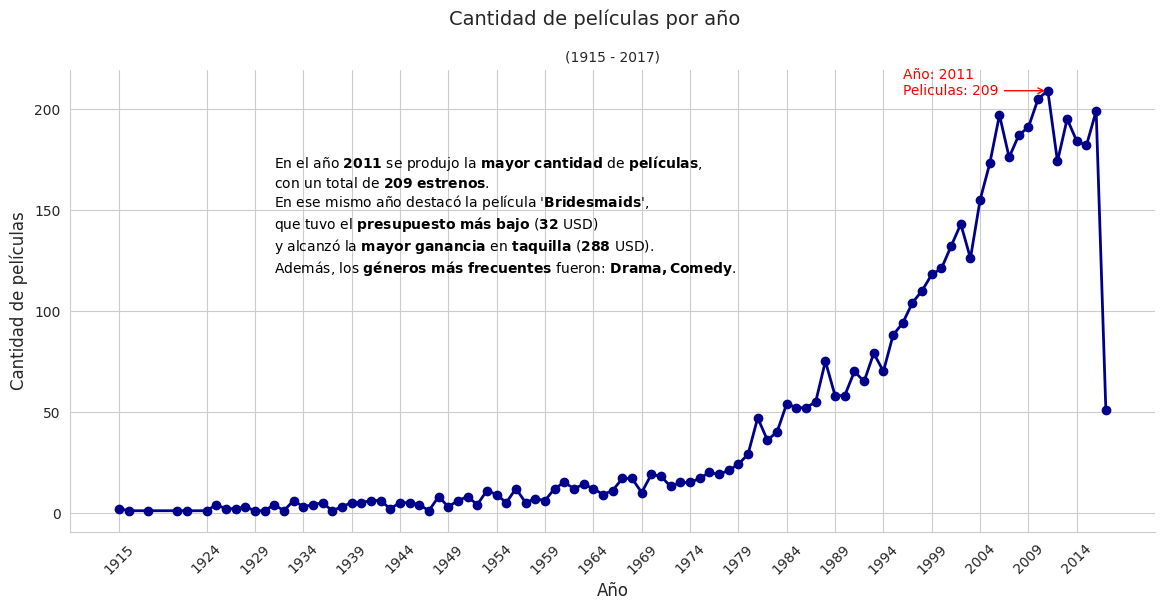

In [ ]:
# line plot 'Peñiculas por año'
fig, ax = plt.subplots(figsize=(14, 6))

ax.plot(
    peliculas_por_año['Año'],
    peliculas_por_año['Cantidad de películas'],
    marker='o', color='darkblue', linewidth=2,
)

fig.suptitle('Cantidad de películas por año', fontsize=14)
ax.set_title('(1915 - 2017)', fontsize=10)

ax.set_xlabel('Año', fontsize=12)
ax.set_ylabel('Cantidad de películas', fontsize=12)

ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

# xticks (salto de años de 5 en 5, rotacion 45)
plt.xticks(ticks = peliculas_por_año['Año'][::5], rotation=45)

# anotacion (Año con mayor peliculas)
plt.annotate(
    f"Año: {max_year}\nPeliculas: {max_movies}\n",
    xy = (max_year, max_movies),
    xytext = (max_year - 15, max_movies-10),
    arrowprops = dict(arrowstyle='->', color='red'),
    fontsize=10,
    color='red'
)


plt.annotate(
    f"En el año $\\mathbf{{{max_year}}}$ se produjo la $\\mathbf{{mayor}}$ $\\mathbf{{cantidad}}$ "
    f"de $\\mathbf{{películas}}$,\n"
    f"con un total de $\\mathbf{{{max_movies}}}$ $\\mathbf{{estrenos}}$.\n"
    f"En ese mismo año destacó la película '$\\mathbf{{{pelicula['original_title']}}}$',\n"
    f"que tuvo el $\\mathbf{{presupuesto}}$ $\\mathbf{{más}}$ $\\mathbf{{bajo}}$ "
    f"($\\mathbf{{{pelicula['budget']:,.0f}}}$ USD)\n"
    f"y alcanzó la $\\mathbf{{mayor}}$ $\\mathbf{{ganancia}}$ en $\\mathbf{{taquilla}}$ "
    f"($\\mathbf{{{pelicula['revenue']:,.0f}}}$ USD).\n"
    f"Además, los $\\mathbf{{géneros}}$ $\\mathbf{{más}}$ $\\mathbf{{frecuentes}}$ fueron: "
    f"$\\mathbf{{{generos}}}$.",
    xy=(max_year, max_movies),
    xytext=(max_year - 80, max_movies - 90),
    fontsize=10,
    color="black"
)



# estilo del grafico plt.style.use('ggplot')
plt.show()

- **Tendencia ascendente:** la producción de películas muestra un crecimiento sostenido a lo largo del siglo XX y principios del XXI, reflejando la expansión global de la industria cinematográfica.

- **Pico en 2011:** ese año se alcanzó el máximo de la serie con 209 películas estrenadas, el punto más alto registrado en el periodo analizado.

- **Estabilización posterior:** tras 2011, la producción se mantiene elevada, aunque con variaciones moderadas en los años siguientes.

- **Crecimiento desde los 2000:** a partir del año 2000 se observa un incremento notable, impulsado por el avance tecnológico (cámaras digitales, software de edición más accesible, distribución en DVD y posteriormente streaming) y el abaratamiento de equipos de producción, lo que democratizó la creación cinematográfica.

- **Impacto cultural y social:** el predominio del género Drama, acompañado por la Comedia, refleja la diversidad de narrativas que buscaban conectar con públicos amplios y procesar colectivamente los cambios sociales y culturales de la época.

- **Transformación del mercado:** la combinación de tecnología y contexto histórico generó un ecosistema donde se produjeron más películas que nunca, con géneros que buscaban tanto entretener como expresar las tensiones y aspiraciones de la sociedad contemporánea.

¿Cuál es el presupuesto promedio y la ganancia promedio?

In [ ]:
# presupuesto y gamacia promedio
presupuesto_promedio = movies_unicos['budget'].mean()
ganacias_promedio = movies_unicos['revenue'].mean()

print(f"Presupuesto promedio: ${presupuesto_promedio:.2f}")
print(f"Ganancia promedio: ${ganacias_promedio:.2f}")

Presupuesto promedio: $23.58
Ganancia promedio: $52.18


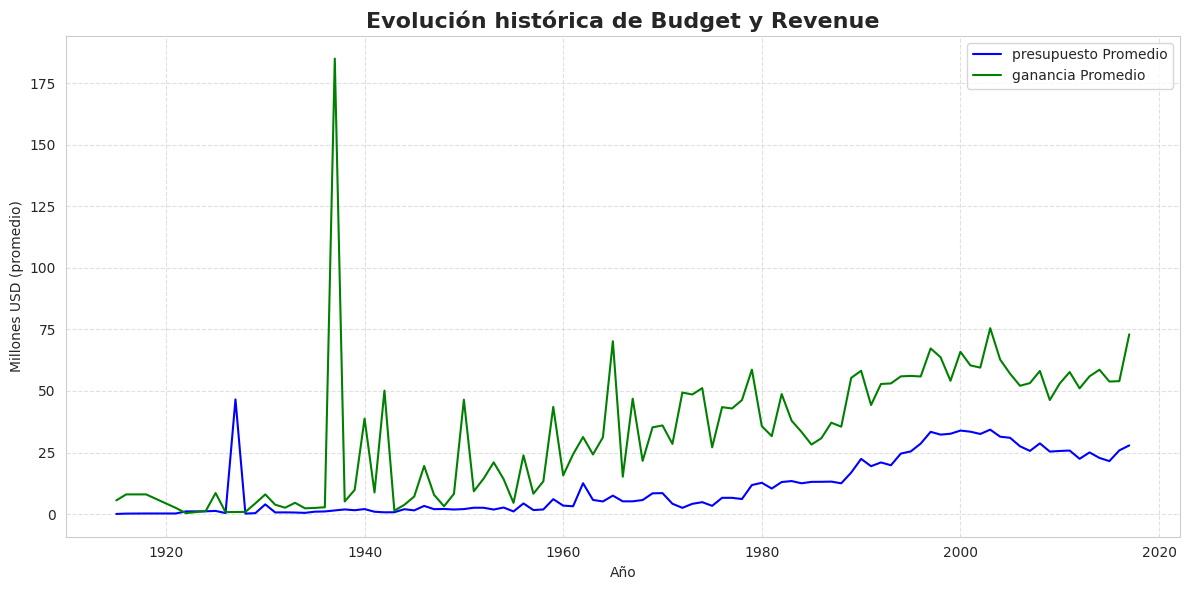

In [ ]:
historico = movies_unicos.groupby(
    movies_unicos['release_date'].dt.year
).agg(
    presupuesto_promedio=('budget', 'mean'),
    ganancia_promedio=('revenue', 'mean')
).reset_index()

# Gráfico de líneas
plt.figure(figsize=(12,6))
sns.lineplot(data=historico, x="release_date", y="presupuesto_promedio", label="presupuesto Promedio", color="blue")
sns.lineplot(data=historico, x="release_date", y="ganancia_promedio", label="ganancia Promedio", color="green")

plt.title("Evolución histórica de Budget y Revenue", fontsize=16, weight="bold")
plt.xlabel("Año")
plt.ylabel("Millones USD (promedio)")
plt.legend()
plt.grid(True, linestyle="--", alpha=0.6)
plt.tight_layout()
plt.show()

In [ ]:
# Datos para graficar
categorias = ['Presupuesto', 'Ganancia']
valores = [presupuesto_promedio, ganacias_promedio]

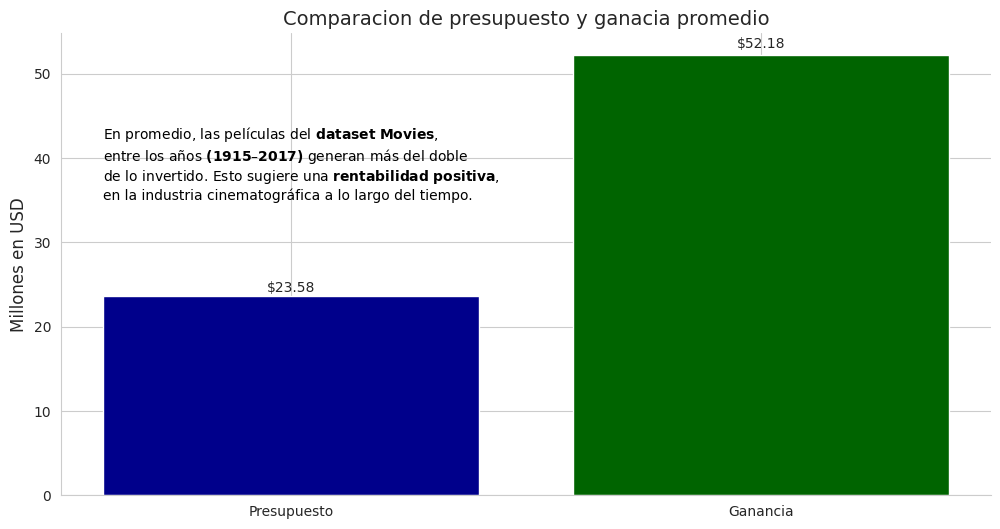

In [ ]:
fig, ax = plt.subplots(figsize=(12, 6))

ax.bar(categorias, valores, color=['darkblue', 'darkgreen'])

ax.set_title('Comparacion de presupuesto y ganacia promedio', fontsize=14)

ax.set_ylabel('Millones en USD', fontsize=12)

ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

# Mostrar valores en las barras
for i, v in enumerate(valores):
    ax.text(
        i, v + v * 0.01,
        f'${v:.2f}',
        ha='center', va='bottom',
        fontsize=10
    )

plt.annotate(
    f"En promedio, las películas del $\\mathbf{{dataset}}$ $\\mathbf{{Movies}}$,\n"
    f"entre los años $\\mathbf{{(1915–2017)}}$ generan más del doble\n"
    f"de lo invertido. Esto sugiere una $\\mathbf{{rentabilidad}}$ $\\mathbf{{positiva}}$,\n"
    f"en la industria cinematográfica a lo largo del tiempo.",
    xy=(0.5, 0.5),
    xytext=(-0.4, 35),
    fontsize=10,
    color="black"
)

plt.show()

**Relación inversión–retorno (presupuesto - ganacia):**

- El hecho de que la ganancia promedio supere ampliamente al presupuesto refleja que, históricamente, el cine ha sido un sector con un retorno atractivo. En términos de ROI (Return on Investment), estamos viendo una proporción aproximada de 2.2 veces la inversión inicial.

**Limitaciones del promedio:**

- Los promedios pueden ocultar la alta variabilidad: hay películas con pérdidas significativas y otras con ganancias extraordinarias.

- El rango temporal (más de 100 años) mezcla contextos muy distintos: inflación, cambios tecnológicos, modelos de distribución, y la aparición de plataformas digitales.

**Contexto histórico:**

- En las primeras décadas del cine, los presupuestos eran mucho más bajos, lo que puede sesgar el promedio hacia cifras menores.

- En épocas recientes, los blockbusters con presupuestos altos también tienden a generar ganancias desproporcionadas, inflando la media.


¿Qué géneros son los más frecuentes?

In [ ]:
# Agrupar por 10 genermos mas frecuentes
generos_mas_frecuentes = (
    movies_unicos['genres_name']
    .value_counts()
    .head(10)
    .reset_index()
)
generos_mas_frecuentes.columns = ['Género', 'Frecuencia']

generos_mas_frecuentes

,Género,Frecuencia
0,Drama,1251
1,Comedy,1013
2,Action,830
3,Horror,318
4,Adventure,291
5,Crime,255
6,Thriller,181
7,Fantasy,118
8,Romance,109
9,Animation,97


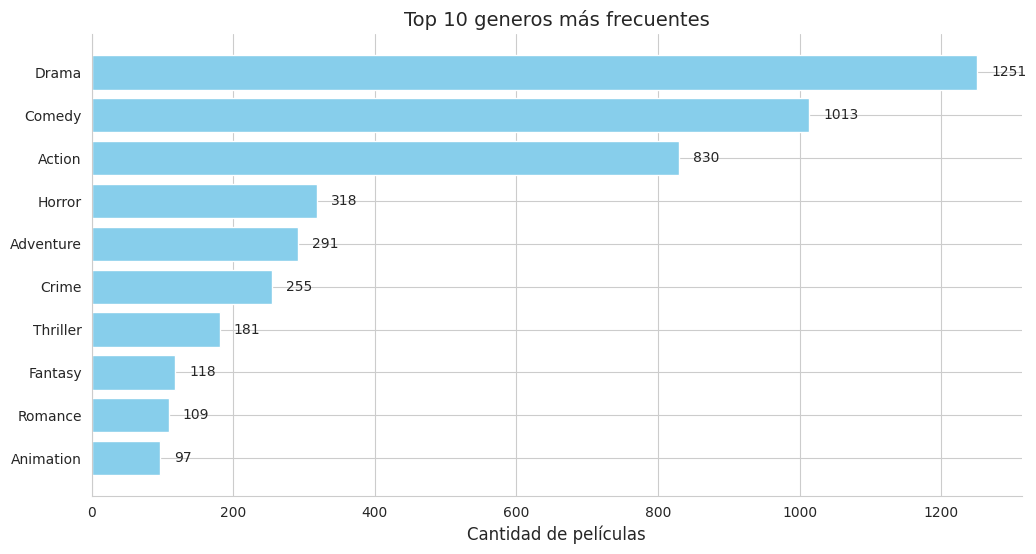

In [ ]:
fig, ax = plt.subplots(figsize=(12, 6))

ax.barh(
    generos_mas_frecuentes['Género'],
    generos_mas_frecuentes['Frecuencia'],
    color='skyblue'
)

ax.set_title('Top 10 generos más frecuentes', fontsize=14)
ax.set_xlabel('Cantidad de películas', fontsize=12)

ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

# Mostrar valores en las barras
for i, v in enumerate(generos_mas_frecuentes['Frecuencia']):
    ax.text(
        v + 20,
        i,
        str(v),
        va='center',
        fontsize=10
    )

# Invertir eje y (mejor orden visual)
ax.invert_yaxis()

# plt.tight.layout()
plt.show()

- **Drama y Comedia** dominan en cantidad de películas (más de 1000 cada uno). Esto refleja que son géneros “seguros” y muy producidos, probablemente porque tienen costos moderados y una audiencia amplia.

- **Acción y Horror** también aparecen con fuerza, pero en menor volumen. Son géneros con públicos específicos y suelen tener presupuestos distintos (acción más alto, horror más bajo).

- Los géneros menos frecuentes **(Animación, Romance, Fantasía)** muestran que, aunque no se producen tanto, sí tienen un nicho claro.

**Conclusión:** La frecuencia no necesariamente implica rentabilidad, sino preferencia de producción. Los estudios producen más dramas y comedias porque son versátiles y menos riesgosos.

¿Qué géneros generan más ingresos en promedio?

In [ ]:
# Agrupar por genero buscando la media en ingresos
generos_ingresos_mean = (
    movies_unicos.groupby('genres_name')['revenue']
    .mean()
    .reset_index()
)
generos_ingresos_mean.columns = ['Género', 'Ingresos promedio (M)']
generos_ingresos_mean = generos_ingresos_mean.sort_values(
    by='Ingresos promedio (M)', ascending=False
)

generos_ingresos_mean

,Género,Ingresos promedio (M)
2,Animation,84.138536
7,Family,76.943555
8,Fantasy,76.132674
1,Adventure,69.250617
15,Science Fiction,66.252721
0,Action,60.338605
18,Thriller,56.844614
10,History,54.038966
3,Comedy,53.746897
14,Romance,49.439933


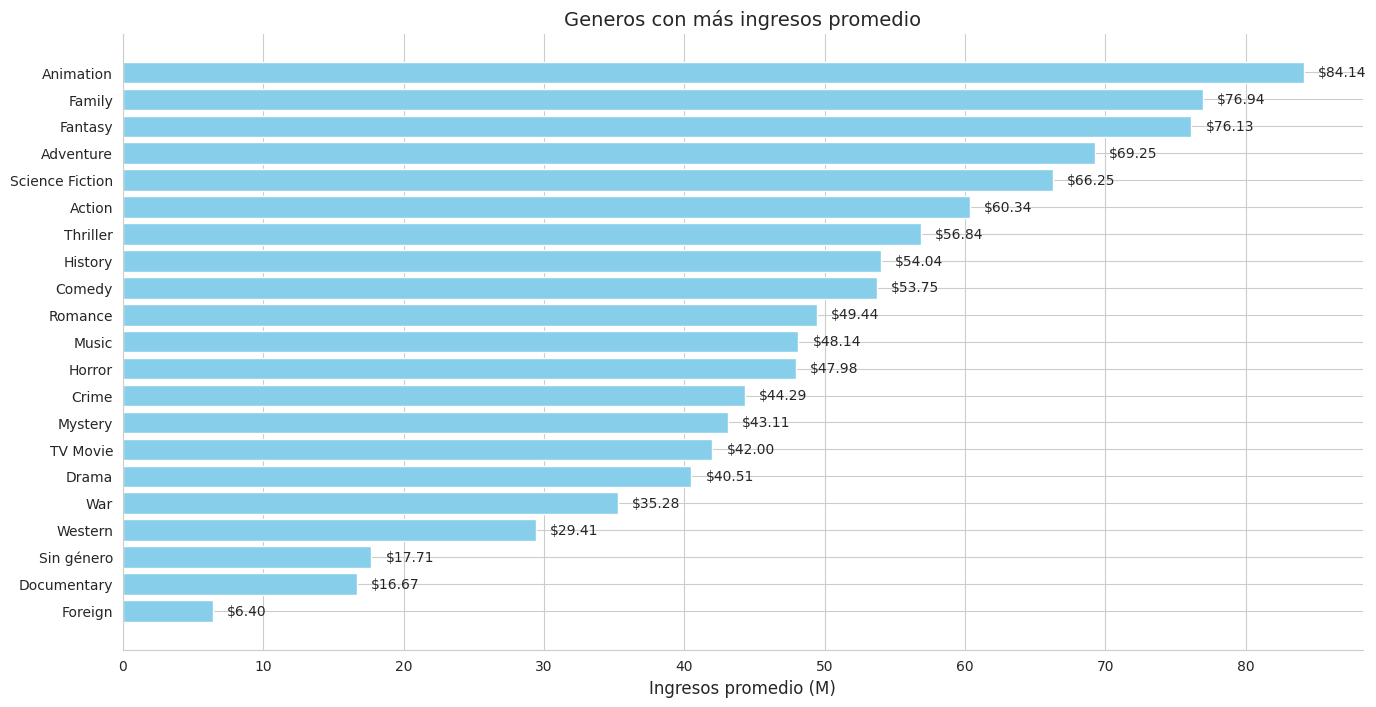

In [ ]:
fig, ax = plt.subplots(figsize=(16, 8))

ax.barh(
    generos_ingresos_mean['Género'],
    generos_ingresos_mean['Ingresos promedio (M)'],
    color='skyblue'
)

ax.set_title('Generos con más ingresos promedio', fontsize=14)
ax.set_xlabel('Ingresos promedio (M)', fontsize=12)

ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

# texto en las barras
for i, v in enumerate(generos_ingresos_mean['Ingresos promedio (M)']):
    ax.text(
        v + 1,
        i,
        f'${v:.2f}',
        va='center',
        fontsize=10
    )

ax.invert_yaxis()

plt.show()

- **Animación, Family y Fantasy** lideran en ingresos promedio (más de 70M USD). Esto indica que, aunque se producen menos películas de estos géneros, suelen ser **blockbusters"taquillazo"** con gran inversión y retorno.

- **Adventure, Sci-Fi y Action** también muestran altos ingresos, confirmando que **los géneros “espectáculo”** tienden a atraer grandes audiencias globales.

- **Drama y Documentary**, pese a ser muy frecuentes, tienen ingresos promedio bajos (40M y 16M respectivamente). Esto sugiere que son géneros más artísticos o de nicho, con menor atractivo comercial masivo.

**Conclusión:** La rentabilidad está más ligada al tipo de género que a la frecuencia de producción. Los géneros familiares y de animación son menos frecuentes pero altamente rentables, mientras que los dramas y comedias son abundantes pero con ingresos más modestos.

- Existe una desconexión entre cantidad y rentabilidad: lo que más se produce (Drama, Comedia) no es lo que más dinero genera.

- Los géneros con alto revenue promedio (Animación, Family, Sci-Fi) suelen requerir grandes presupuestos y tecnología avanzada, lo que limita su frecuencia pero maximiza su impacto económico.

- Los géneros con alta frecuencia y bajo revenue (Drama, Documentary) cumplen un rol cultural y artístico, sosteniendo diversidad en la industria, aunque no sean los más lucrativos.

Esto sugiere que los estudios equilibran su portafolio: producen muchos títulos de bajo riesgo (dramas, comedias) y apuestan ocasionalmente por grandes producciones de alto retorno (animación, sci-fi, aventuras).

En términos de estrategia de negocio, podriamos argumentar que:

- Los estudios buscan volumen y estabilidad con dramas/comedia.

- Reservan inversión fuerte para géneros con potencial de blockbuster.

- La combinación asegura tanto flujo constante de estrenos como picos de ingresos.

📈 Visualizaciones

- Histograma de presupuestos e ingresos

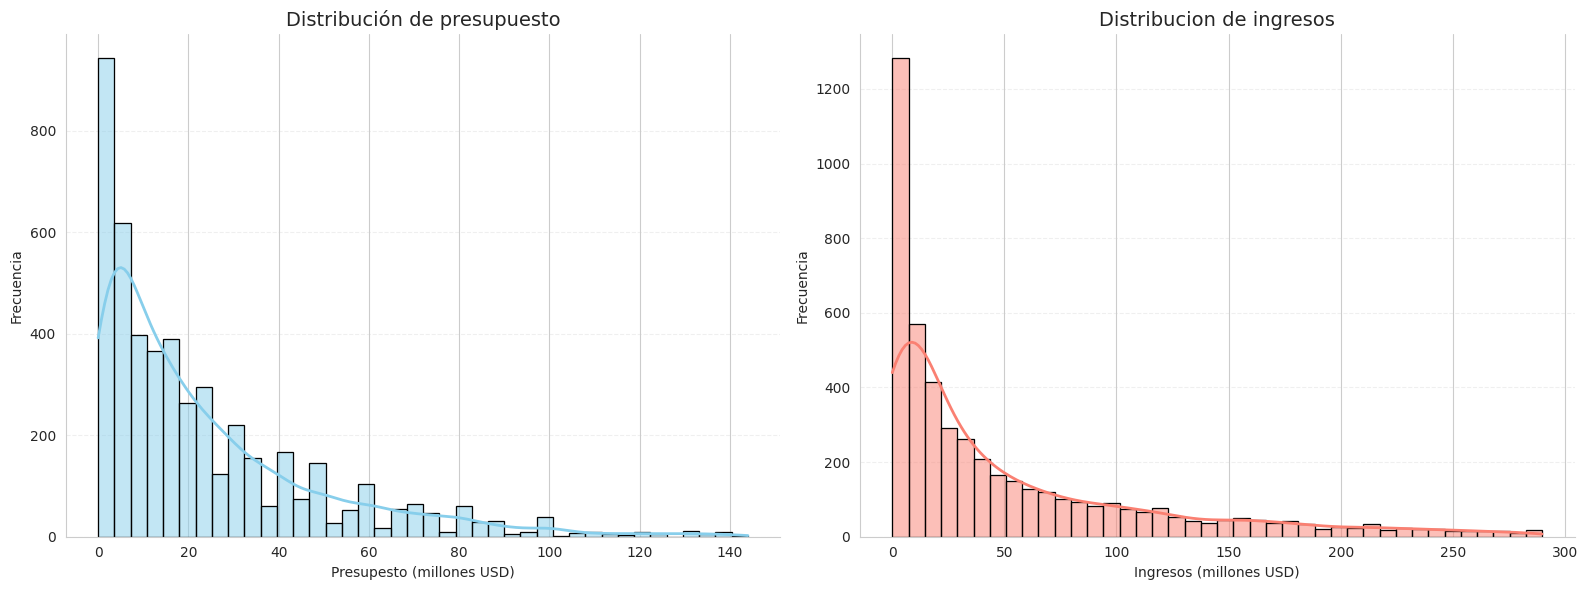

In [ ]:
# Estilo visual
sns.set_style('whitegrid')
sns.set_palette('pastel')

# Dos graficos (histplot)
fig, axes = plt.subplots(1, 2, figsize=(16,6))

# Histrgrama presupuesto (budget)
sns.histplot(
    movies_unicos['budget'],
    bins=40, kde=True,
    color='skyblue', edgecolor='black',
    line_kws={'linewidth': 2},
    ax=axes[0]
)
axes[0].set_title('Distribución de presupuesto', fontsize=14)
axes[0].set_xlabel('Presupesto (millones USD)')
axes[0].set_ylabel('Frecuencia')
axes[0].spines['top'].set_visible(False)
axes[0].spines['right'].set_visible(False)
axes[0].grid(axis='y', linestyle='--', alpha=0.3)

# Histograma ingresos (revenue)
sns.histplot(
    movies_unicos['revenue'],
    bins=40, kde=True,
    color='salmon', edgecolor='black',
    line_kws={'linewidth': 2},
    ax=axes[1]
)
axes[1].set_title('Distribucion de ingresos', fontsize=14)
axes[1].set_xlabel('Ingresos (millones USD)')
axes[1].set_ylabel('Frecuencia')
axes[1].spines['top'].set_visible(False)
axes[1].spines['right'].set_visible(False)
axes[1].grid(axis='y', linestyle='--', alpha=0.3)

plt.tight_layout()
plt.show()

- Gráfico de barras: top 10 géneros más comunes

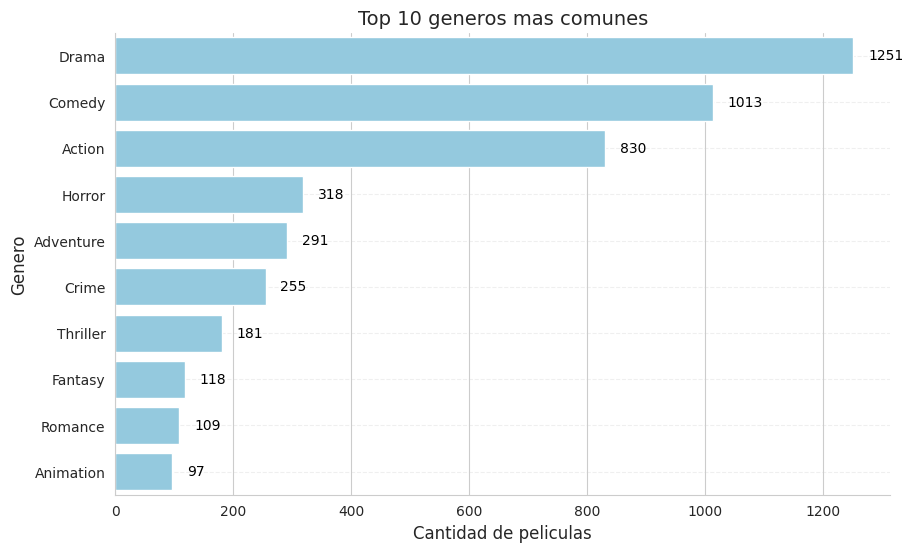

In [ ]:
# Cantidad de peliculas por genero
conteo_generos = (
    movies_unicos['genres_name']
    .value_counts()
    .head(10)
)

# Estilo visual
sns.set_style('whitegrid')
sns.set_palette('pastel')

# Grafico
fig, ax = plt.subplots(figsize=(10,6))

sns.barplot(
    x=conteo_generos.values,
    y=conteo_generos.index,
    color='skyblue',
    ax=ax
)
ax.set_title('Top 10 generos mas comunes', fontsize=14)
ax.set_xlabel('Cantidad de peliculas', fontsize=12)
ax.set_ylabel('Genero', fontsize=12)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)


for i, v in enumerate(conteo_generos):
    ax.text(
        v + 25,
        i,
        str(v),
        va='center',
        fontsize=10,
        color='black'
    )

ax.grid(axis='y', linestyle='--', alpha=0.3)

plt.show()

#💰 3. Análisis de rentabilidad

📌 Dataset: movies_metadata.csv (movies_metadata_normalizado.csv)

Crea nuevas columnas:

- profit = revenue - budget

- roi = profit / budget

Responde:

- ¿Qué género tiene mayor ROI promedio?

- ¿Las películas caras siempre generan más ganancias?

- Top 10 películas más rentables (ROI).

📊 Gráficos:

- Scatter plot: presupuesto vs ingresos

- Boxplot: ROI por género

**ROI (Retorno sobre la Inversión)**

In [ ]:
movies = movies_unicos.copy()
movies['profit'] = movies['revenue'] - movies['budget']
movies['roi'] = (movies['profit'] / movies['budget'])*100
# redondear a 2 decimales
movies = movies.round(2)

¿Qué género tiene mayor ROI promedio?

In [ ]:
genero_rio_mean = (
    movies.groupby('genres_name')['roi']
    .mean()
    .reset_index()
    .sort_values(by='roi', ascending=False)
)
genero_rio_mean.columns = ['Género', 'ROI promedio']

genero_rio_mean.head(10)

,Género,ROI promedio
11,Horror,6619.102642
5,Documentary,1701.252444
9,Foreign,885.512500
17,TV Movie,740.000000
13,Mystery,662.856032
20,Western,651.655357
0,Action,544.547554
7,Family,532.719000
2,Animation,521.729072
10,History,419.759643


¿Las películas caras siempre generan más ganancias?

Top 10 películas más rentables (ROI).



In [ ]:
peliculas_mas_rentables = movies[['original_title','budget','revenue','roi']]
peliculas_mas_rentables = (
    peliculas_mas_rentables
    .sort_values(by='roi', ascending=False)
    .drop_duplicates(subset='original_title')
    .head(10)
)

peliculas_mas_rentables

,original_title,budget,revenue,roi
181825,Paranormal Activity,0.02,193.36,1288938.67
30228,The Blair Witch Project,0.06,248.00,413233.33
397598,대호,0.00,11.08,221568.98
40231,Eraserhead,0.01,7.00,69900.00
49833,猛龍過江,0.13,85.00,65284.62
25880,Pink Flamingos,0.01,6.00,49900.00
91776,Super Size Me,0.06,28.58,43861.66
343195,The Gallows,0.10,42.66,42564.41
110243,Open Water,0.13,54.67,41952.27
27029,The Texas Chain Saw Massacre,0.08,30.86,36204.71


In [ ]:
!apt-get install -y fonts-noto-cjk

Reading package lists... Done
Building dependency tree... Done
Reading state information... Done
fonts-noto-cjk is already the newest version (1:20220127+repack1-1).
0 upgraded, 0 newly installed, 0 to remove and 2 not upgraded.


In [ ]:
import matplotlib.font_manager as fm
# Listar todas las fuentes disponibles
for font in fm.findSystemFonts(fontpaths=None, fontext='ttf'):
    if "NotoSansCJK" in font or "Noto" in font:
        print(font)


/usr/share/fonts/opentype/noto/NotoSerifCJK-Regular.ttc
/usr/share/fonts/opentype/noto/NotoSansCJK-Regular.ttc
/usr/share/fonts/opentype/noto/NotoSerifCJK-Bold.ttc
/usr/share/fonts/opentype/noto/NotoSansCJK-Bold.ttc


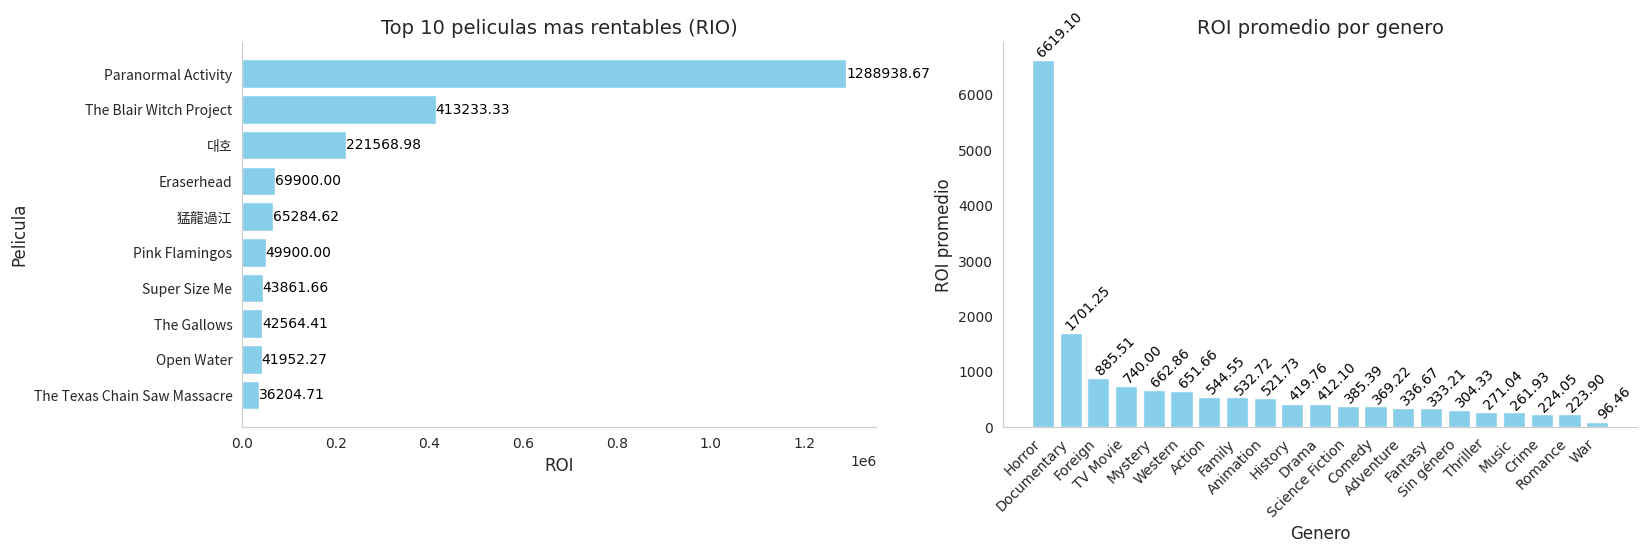

In [ ]:
# Usa la ruta que salio en font_manager
font_path = "/usr/share/fonts/opentype/noto/NotoSansCJK-Regular.ttc"
font_prop = fm.FontProperties(fname=font_path)

# Peñiculas rentables por RIO
fig, axes = plt.subplots(1,2, figsize=(18,5))

fig1 = axes[0].barh(
    peliculas_mas_rentables['original_title'],
    peliculas_mas_rentables['roi'],
    color='skyblue'
)
axes[0].set_title('Top 10 peliculas mas rentables (RIO)', fontsize=14)
axes[0].set_xlabel('ROI', fontsize=12)
axes[0].set_ylabel('Pelicula', fontsize=12)

# Aplicar la fuente a las etiquetas del eje Y
for label in axes[0].get_yticklabels():
    label.set_fontproperties(font_prop)

axes[0].spines['top'].set_visible(False)
axes[0].spines['right'].set_visible(False)

axes[0].bar_label(fig1, fontsize=10, color='black', fmt='%.2f')

axes[0].invert_yaxis()
axes[0].grid(visible=False)

fig2 = axes[1].bar(
    genero_rio_mean['Género'],
    genero_rio_mean['ROI promedio'],
    color='skyblue'
)
axes[1].set_title('ROI promedio por genero', fontsize=14)
axes[1].set_xlabel('Genero', fontsize=12)

axes[1].tick_params(axis='x', labelrotation=45, labelsize=10)
for label in axes[1].get_xticklabels():
    label.set_ha('right')

axes[1].set_ylabel('ROI promedio', fontsize=12)

axes[1].spines['top'].set_visible(False)
axes[1].spines['right'].set_visible(False)

labels = axes[1].bar_label(fig2, fontsize=10, color='black', fmt='%.2f', rotation=45)
for label in labels:
    x, y = label.get_position()
    label.set_position((x + 12, y))
axes[1].grid(visible=False)

plt.show()

- **Paranormal Activity y The Blair Witch Project** destacan con un ROI extraordinario (más de 1 millón y 400 mil respectivamente). Esto refleja un patrón clásico: películas de bajo presupuesto en el género de terror logran retornos desproporcionados cuando conectan con el público.

- Varias películas en la lista son independientes o de nicho **(Eraserhead, Pink Flamingos, Open Water)**. Esto sugiere que la rentabilidad no depende de grandes estudios, sino de costos bajos y un marketing efectivo.

- Presencia de títulos asiáticos (대호, 猛龍過江) muestra que el fenómeno no es exclusivo de Hollywood, sino que se repite en otros mercados.

- El ROI extremo se debe a presupuestos mínimos (decenas de miles de dólares) frente a ingresos multimillonarios. No necesariamente significa que estas películas sean las más vistas, sino las más eficientes en relación inversión/ganancia.
---
- El género Horror lidera con diferencia (≈ 6,600), confirmando lo visto en el gráfico **Top 10 películas más rentables (ROI)**: alta rentabilidad por bajo costo de producción.

- Documentary y Foreign también muestran ROI elevado. Esto puede deberse a presupuestos reducidos y distribución selectiva que maximiza beneficios.

- **Géneros tradicionales como Drama, Comedy y Adventure tienen un ROI mucho más bajo (≈300–400).** Aunque generan ingresos altos en bruto, sus presupuestos también son elevados, lo que reduce la eficiencia. **Sin embargo, pueden considerarse una zona segura para los estudios**, ya que cuentan con una audiencia estable y amplia que asegura retornos moderados y reduce la probabilidad de pérdidas significativas.

- Romance y War aparecen al final con ROI mínimo (≈ 96). Esto indica que son géneros de mayor riesgo financiero: requieren inversión pero no garantizan retorno proporcional.


📊 Gráficos:

- Scatter plot: presupuesto vs ingresos

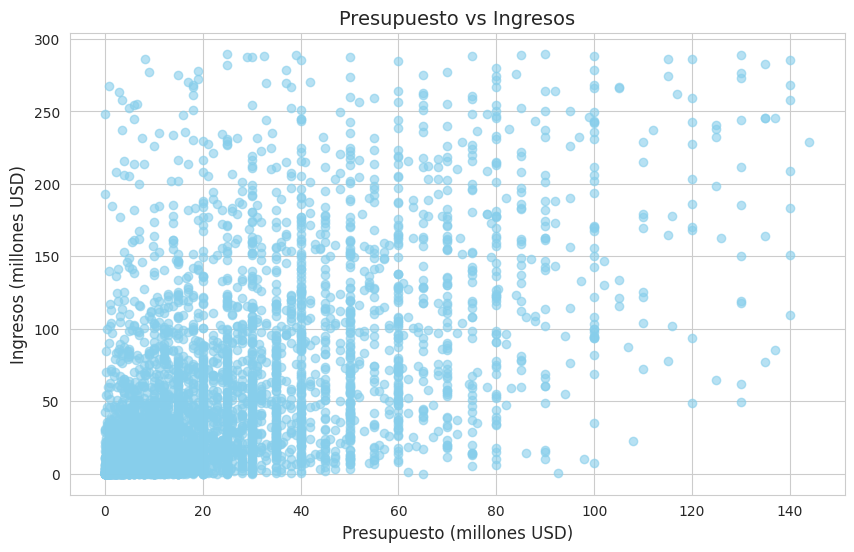

In [ ]:
fig, ax = plt.subplots(figsize=(10,6))

ax.scatter(
    movies['budget'],
    movies['revenue'],
    alpha=0.6,
    color='skyblue'
)
ax.set_title('Presupuesto vs Ingresos', fontsize=14)
ax.set_xlabel('Presupuesto (millones USD)', fontsize=12)
ax.set_ylabel('Ingresos (millones USD)', fontsize=12)

plt.show()

- Boxplot: ROI por género

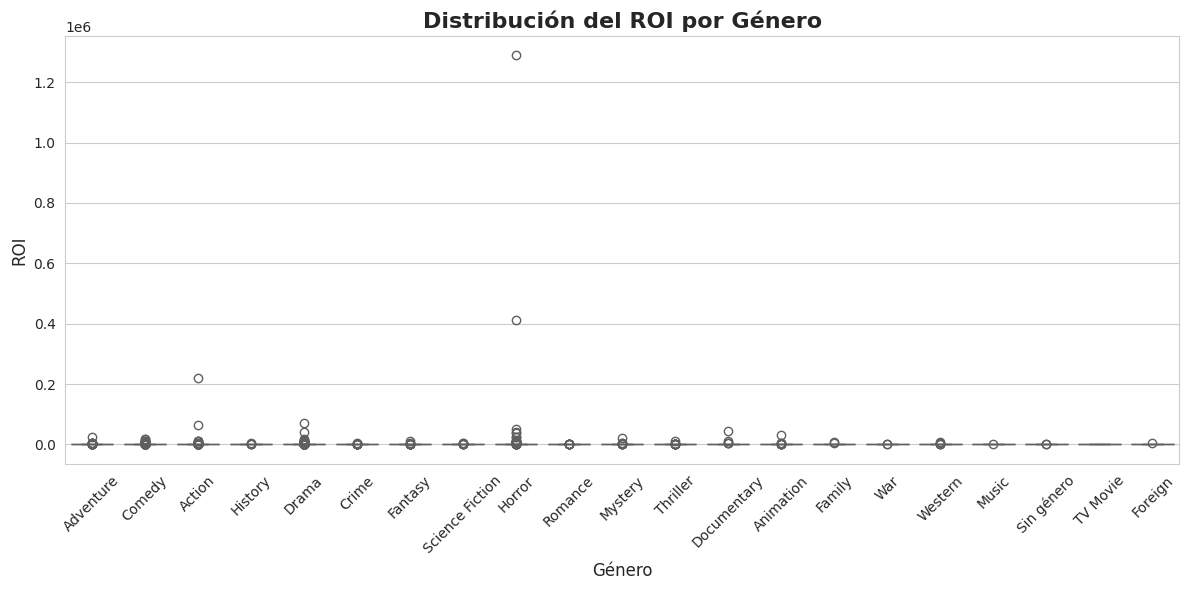

In [ ]:
# boxplot de rio por genero
plt.figure(figsize=(12,6))
sns.boxplot(
    data=movies,
    x="genres_name",
    y="roi",
    hue="genres_name",   # asigna el color por género
    palette="Set3",
    legend=False         # evita que aparezca una leyenda redundante
)

plt.title("Distribución del ROI por Género", fontsize=16, weight="bold")
plt.xlabel("Género", fontsize=12)
plt.ylabel("ROI", fontsize=12)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


#⭐ 4. Análisis de calificaciones de usuarios

📌 Dataset: ratings.csv o ratings_small.csv

Tareas:

Calcular:

- Rating promedio por película

- Número de votos por película

- Unir ratings con movies_metadata.csv

Responder:

- ¿Las películas mejor calificadas generan más ingresos?

- ¿Existe relación entre popularidad y rating?

📈 Visualización:

- Scatter plot: rating promedio vs ingresos

In [ ]:
df_ratings = pd.read_csv('/content/ratings_small.csv', on_bad_lines='skip')
ratings = df_ratings.copy()
ratings.sample(3)

,userId,movieId,rating,timestamp
24208,175,3114,4.0,1052884243
59191,428,77455,4.5,1304136806
63389,457,4571,3.0,1471384740


In [ ]:
# Corregir tipo de dato (timesramp) a tipo fecha
ratings['date'] = pd.to_datetime(
    ratings['timestamp'], unit='s',
    errors='coerce'
)
ratings['date'] = ratings['date'].dt.date
ratings = ratings.drop(columns=['timestamp'])
ratings.sample(1)

,userId,movieId,rating,date
81566,555,593,3.0,1996-05-14


In [ ]:
# info (datos nulos)
ratings.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100004 entries, 0 to 100003
Data columns (total 4 columns):
 #   Column   Non-Null Count   Dtype  
---  ------   --------------   -----  
 0   userId   100004 non-null  int64  
 1   movieId  100004 non-null  int64  
 2   rating   100004 non-null  float64
 3   date     100004 non-null  object 
dtypes: float64(1), int64(2), object(1)
memory usage: 3.1+ MB


In [ ]:
# Guardar df normalizado
ratings.to_csv('ratings_small_normalizado.csv', index=False)


Unir ratings (ratings_small_normalizado) con movies_metadata.csv (movies_metadata_normalizado)

In [ ]:
# Reducir el DataFrame 'movies' antes de realizar el merge.
# De lo contrario, el volumen de datos es demasiado grande y Google Colab puede quedarse sin memoria RAM.
col_movies = [
    'id', 'original_title', 'release_date', 'popularity',
    'genres_name', 'vote_count', 'budget', 'revenue'
]
#, 'profit', 'roi'
movies_merge = normalizado_movies[col_movies]
movies_merge = movies_merge.copy()   # evita el SettingWithCopyWarning
movies_merge['id'] = movies_merge['id'].astype(int)

#agregar rio y profit del df movies unicos
col_movies_unicos = [
    'id', 'profit', 'roi'
]
col_merge = movies[col_movies_unicos]
col_merge = col_merge.copy()
col_merge['id'] = col_merge['id'].astype(int)

movies_merge = movies_merge.merge(
    col_merge,
    left_on = 'id',
    right_on = 'id',
    how = 'left'
)
movies_merge.sample(3)

,id,original_title,release_date,popularity,genres_name,vote_count,budget,revenue,profit,roi
14196,10385,Hanging Up,2000-02-16,6.474767,Comedy,42.0,40.0,36.037909,-3.96,-9.91
4311,409,The English Patient,1996-11-14,15.564161,War,559.0,27.0,231.976425,204.98,759.17
75448,48138,Unknown,2011-02-16,14.443599,Mystery,1288.0,30.0,130.786397,100.79,335.95


In [ ]:
movies_merge.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 104066 entries, 0 to 104065
Data columns (total 10 columns):
 #   Column          Non-Null Count   Dtype         
---  ------          --------------   -----         
 0   id              104066 non-null  int64         
 1   original_title  104066 non-null  object        
 2   release_date    104066 non-null  datetime64[ns]
 3   popularity      104066 non-null  float64       
 4   genres_name     104066 non-null  object        
 5   vote_count      104066 non-null  float64       
 6   budget          104066 non-null  float64       
 7   revenue         104066 non-null  float64       
 8   profit          104066 non-null  float64       
 9   roi             104066 non-null  float64       
dtypes: datetime64[ns](1), float64(6), int64(1), object(2)
memory usage: 7.9+ MB


In [ ]:
# megre
ratings_movies = (
    ratings.merge(
        movies_merge,
        left_on = 'movieId',
        right_on = 'id',
        how = 'left'
    )
)
ratings_movies.sample(3)

,userId,movieId,rating,date,id,original_title,release_date,popularity,genres_name,vote_count,budget,revenue,profit,roi
315253,358,2252,4.0,2000-05-04,2252.0,Eastern Promises,2007-09-14,9.897909,Crime,867.0,51.5,55.112356,3.61,7.01
18248,19,612,3.0,1997-02-06,612.0,Munich,2005-12-22,9.668761,Drama,706.0,70.0,130.358911,60.36,86.23
531987,564,612,4.0,2000-11-21,612.0,Munich,2005-12-22,9.668761,Thriller,706.0,70.0,130.358911,60.36,86.23


Es necesario eliminar los datos nulos

In [ ]:
ratings_movies = ratings_movies.dropna()
ratings_movies.info()

<class 'pandas.core.frame.DataFrame'>
Index: 556125 entries, 10 to 638040
Data columns (total 14 columns):
 #   Column          Non-Null Count   Dtype         
---  ------          --------------   -----         
 0   userId          556125 non-null  int64         
 1   movieId         556125 non-null  int64         
 2   rating          556125 non-null  float64       
 3   date            556125 non-null  object        
 4   id              556125 non-null  float64       
 5   original_title  556125 non-null  object        
 6   release_date    556125 non-null  datetime64[ns]
 7   popularity      556125 non-null  float64       
 8   genres_name     556125 non-null  object        
 9   vote_count      556125 non-null  float64       
 10  budget          556125 non-null  float64       
 11  revenue         556125 non-null  float64       
 12  profit          556125 non-null  float64       
 13  roi             556125 non-null  float64       
dtypes: datetime64[ns](1), float64(8), int64(

In [ ]:
# Guardar nuevo dataframe (merge ratings movies)
ratings_movies.to_csv('merge_ratings_movies.csv', index=False)

Rating promedio por película y Número de votos por película

In [ ]:
resumen_peliculas = (
    ratings_movies.groupby(['id', 'original_title'], as_index=False)
    .agg(
        rating_promedio=('rating', 'mean'),   # promedio de ratings
        num_votos=('rating', 'count'),        # cantidad de votos (usuarios)
        vote_count=('vote_count', 'max'),     # votos oficiales de TMDB
        budget=('budget', 'max'),             # métricas financieras
        revenue=('revenue', 'max'),
        profit=('profit', 'max'),
        roi=('roi', 'max')
    ).sort_values(by='roi', ascending=False)
)
resumen_peliculas[resumen_peliculas["num_votos"] < 0]

resumen_peliculas

,id,original_title,rating_promedio,num_votos,vote_count,budget,revenue,profit,roi
251,692.0,Pink Flamingos,2.000000,3,111.0,0.012,6.000000,5.99,49900.00
28,83.0,Open Water,3.000000,6,320.0,0.130,54.667954,54.54,41952.27
328,948.0,Halloween,3.590909,44,1066.0,0.300,70.000000,69.70,23233.33
289,838.0,American Graffiti,3.817073,246,330.0,0.777,140.000000,139.22,17918.02
752,5723.0,Once,4.000000,9,457.0,0.160,20.710513,20.55,12844.07
...,...,...,...,...,...,...,...,...,...
4,19.0,Metropolis,2.597826,368,666.0,92.620,0.650422,-91.97,-99.30
166,452.0,Idioterne,4.000000,192,107.0,2.500,0.007235,-2.49,-99.71
658,3097.0,"The Tulse Luper Suitcases, Part 1: The Moab Story",3.708333,720,5.0,10.000,0.025800,-9.97,-99.74
891,116977.0,Foodfight!,2.666667,24,28.0,65.000,0.073706,-64.93,-99.89


/tmp/ipykernel_2487/1440350070.py:31: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  rating_por_pop = resumen_peliculas.groupby("pop_cat")["rating_promedio"].mean().reset_index()


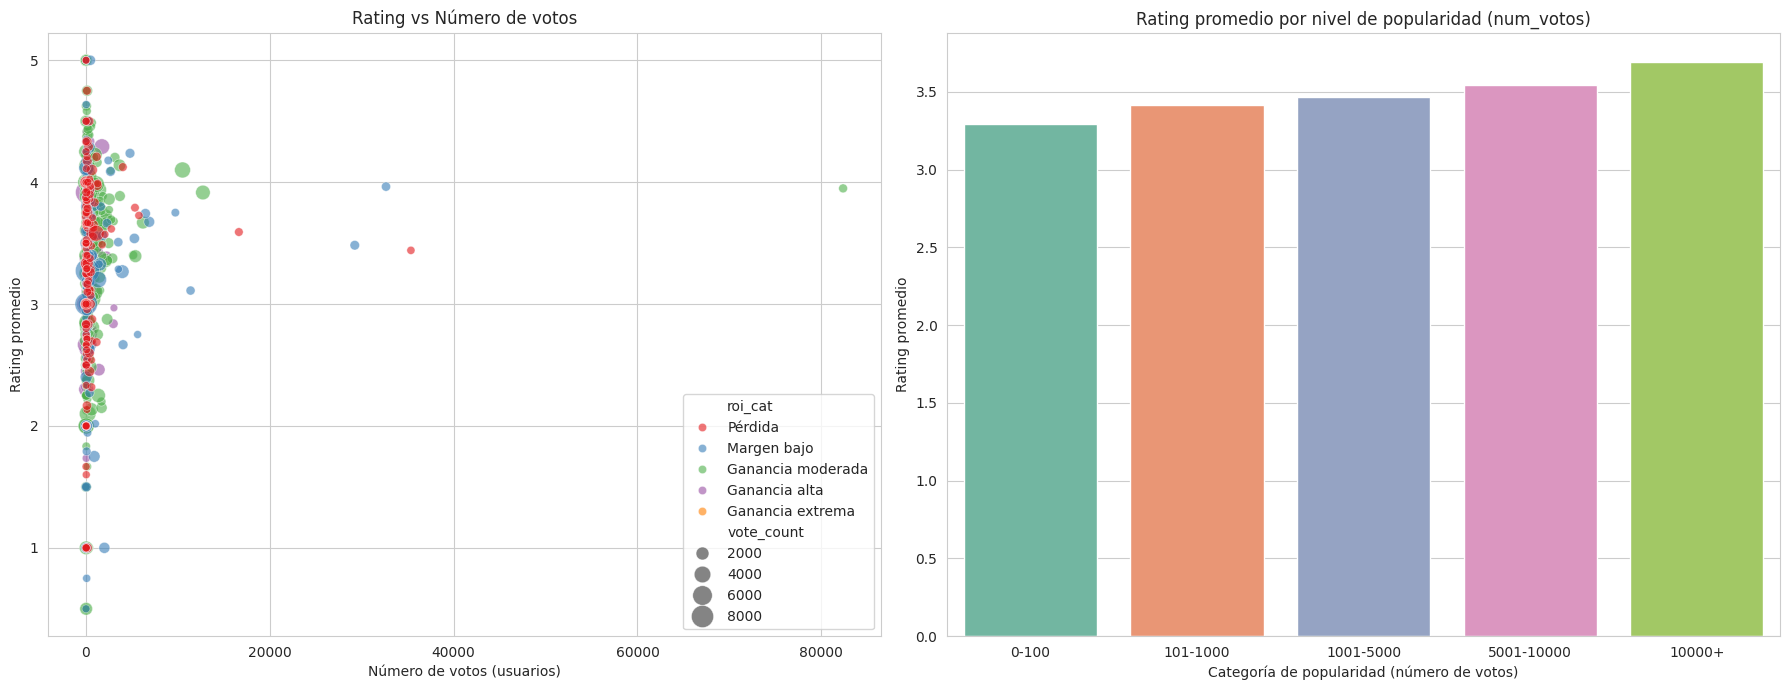

In [ ]:
# Crear categorías de ROI
bins = [-100, 0, 100, 1000, 10000, resumen_peliculas["roi"].max()]
labels = ["Pérdida", "Margen bajo", "Ganancia moderada", "Ganancia alta", "Ganancia extrema"]
resumen_peliculas["roi_cat"] = pd.cut(resumen_peliculas["roi"], bins=bins, labels=labels)

fig, axes = plt.subplots(1, 2, figsize=(18,7))

# Gráfico 1: Rating vs Número de votos (scatter)
sns.scatterplot(
    data=resumen_peliculas,
    x="num_votos",
    y="rating_promedio",
    size="vote_count",
    hue="roi_cat",
    palette="Set1",
    alpha=0.6,
    sizes=(30, 300),
    ax=axes[0]
)
axes[0].set_title("Rating vs Número de votos")
axes[0].set_xlabel("Número de votos (usuarios)")
axes[0].set_ylabel("Rating promedio")

# Gráfico 2: Barras comparando rating promedio por rangos de popularidad (num_votos)
# Creamos rangos de popularidad
bins_pop = [0, 100, 1000, 5000, 10000, resumen_peliculas["num_votos"].max()]
labels_pop = ["0-100", "101-1000", "1001-5000", "5001-10000", "10000+"]
resumen_peliculas["pop_cat"] = pd.cut(resumen_peliculas["num_votos"], bins=bins_pop, labels=labels_pop)

# Calculamos promedio de rating por categoría de popularidad
rating_por_pop = resumen_peliculas.groupby("pop_cat")["rating_promedio"].mean().reset_index()

sns.barplot(
    data=rating_por_pop,
    x="pop_cat",
    y="rating_promedio",
    palette="Set2",
    hue="pop_cat",
    ax=axes[1]
)
axes[1].set_title("Rating promedio por nivel de popularidad (num_votos)")
axes[1].set_xlabel("Categoría de popularidad (número de votos)")
axes[1].set_ylabel("Rating promedio")

plt.tight_layout()
plt.show()



In [ ]:
# Correlación entre rating y número de votos
corr_rating_votos = resumen_peliculas[['rating_promedio','num_votos']].corr()

# Correlación entre rating y vote_count (otra métrica de votos oficiales)
corr_rating_vote_count = resumen_peliculas[['rating_promedio','vote_count']].corr()

print("Correlación rating vs num_votos:\n", corr_rating_votos)
print("\nCorrelación rating vs vote_count:\n", corr_rating_vote_count)


Correlación rating vs num_votos:
                  rating_promedio  num_votos
rating_promedio         1.000000   0.055233
num_votos               0.055233   1.000000

Correlación rating vs vote_count:
                  rating_promedio  vote_count
rating_promedio         1.000000   -0.010128
vote_count             -0.010128    1.000000


¿Las películas mejor calificadas generan más ingresos?



Lo que se observa en el grafico es que no hay una relación directa:

- Algunas películas con rating alto aparecen en categorías de pérdida o margen bajo.

- Otras con rating medio (3–4) sí logran ganancia alta o incluso extrema.

Esto sugiere que la calidad percibida por los usuarios (rating) no garantiza ingresos altos. Factores como presupuesto, marketing, distribución y género influyen mucho más en la rentabilidad.

No necesariamente. Las películas mejor calificadas no siempre generan más ingresos; la relación es débil y depende de otros factores.

¿Existe relación entre popularidad y rating?

La relación es muy débil. Aunque las películas más populares (con más votos) muestran en promedio un rating ligeramente superior, la correlación estadística es casi nula. Esto significa que la popularidad no garantiza una mejor calificación: hay películas muy votadas con ratings bajos y películas poco votadas con ratings altos.

📈 Visualización:

- Scatter plot: rating promedio vs ingresos

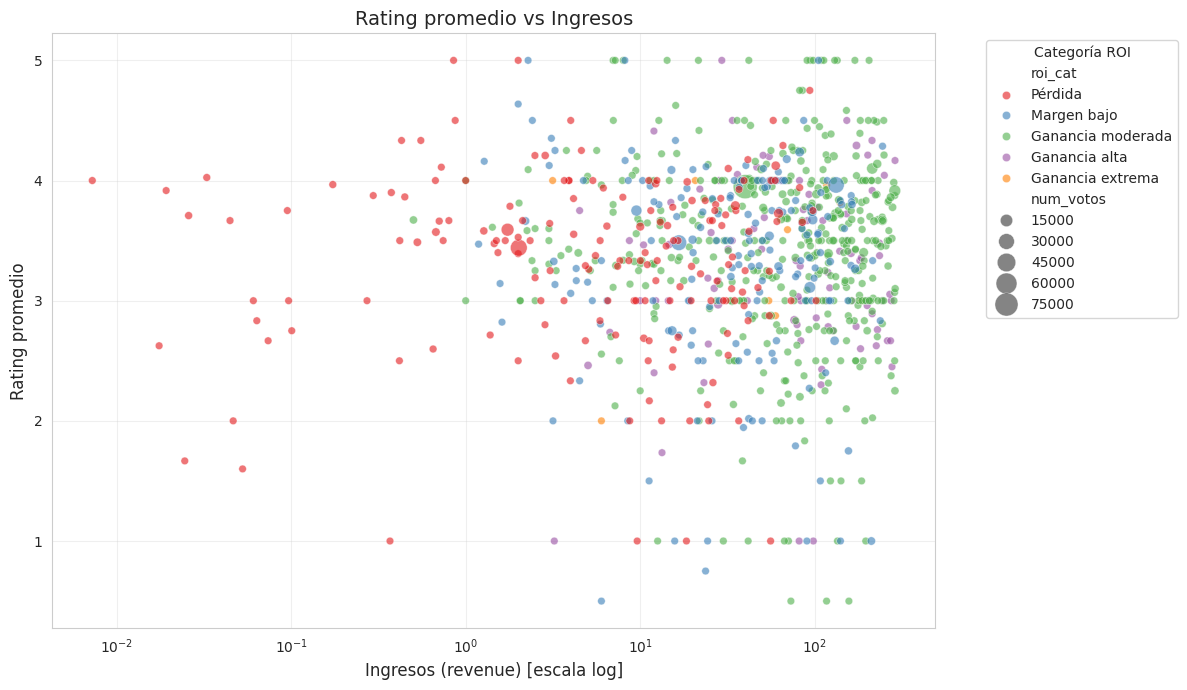

In [ ]:
plt.figure(figsize=(12,7))

sns.scatterplot(
    data=resumen_peliculas,
    x="revenue",             # ingresos
    y="rating_promedio",     # rating promedio
    size="num_votos",        # tamaño de puntos según popularidad
    hue="roi_cat",           # color según categoría ROI
    palette="Set1",
    alpha=0.6,
    sizes=(30, 300)
)

plt.xscale("log")  # escala logarítmica para ingresos (suelen tener valores muy grandes)
plt.title("Rating promedio vs Ingresos", fontsize=14)
plt.xlabel("Ingresos (revenue) [escala log]", fontsize=12)
plt.ylabel("Rating promedio", fontsize=12)
plt.grid(alpha=0.3)
plt.legend(title="Categoría ROI", bbox_to_anchor=(1.05, 1), loc="upper left")
plt.tight_layout()
plt.show()


#🎭 5. Directores y actores más exitosos

📌 Dataset: credits.csv

Tareas:

Extraer:

- Director de cada película

- Actores principales

- Unir con ingresos (movies_metadata.csv)

Responder:

- Top 10 directores con mayor ingreso promedio

- Top 10 actores más rentables

¿Un buen director impacta en el éxito económico?

In [ ]:
df_credits = pd.read_csv('/content/credits.csv', on_bad_lines='skip')
credits = df_credits.copy()
credits.sample(3)

,cast,crew,id
28504,"[{'cast_id': 1, 'character': 'Charleston', 'cr...","[{'credit_id': '52fe46f7c3a36847f811c6ad', 'de...",46448
38930,"[{'cast_id': 5, 'character': 'Em', 'credit_id'...","[{'credit_id': '558f6a0dc3a3687fcb000588', 'de...",346469
32341,"[{'cast_id': 2, 'character': 'Narrator', 'cred...","[{'credit_id': '52fe4ed8c3a36847f82ab8cf', 'de...",243026


In [ ]:
# Normalizar las columnas con listas de diccionarios
credits_cast = normalizar_lista_diccionarios(credits, 'cast')

In [ ]:
credits_crew = normalizar_lista_diccionarios(credits, 'crew')

In [ ]:
normalizado_credits = credits_cast.merge(credits_crew, on='id', how='outer')

In [ ]:
normalizado_credits.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9495072 entries, 0 to 9495071
Data columns (total 18 columns):
 #   Column             Dtype  
---  ------             -----  
 0   crew               object 
 1   id                 int64  
 2   cast_cast_id       float64
 3   cast_character     object 
 4   cast_credit_id     object 
 5   cast_gender        float64
 6   cast_id            float64
 7   cast_name          object 
 8   cast_order         float64
 9   cast_profile_path  object 
 10  cast               object 
 11  crew_credit_id     object 
 12  crew_department    object 
 13  crew_gender        float64
 14  crew_id            float64
 15  crew_job           object 
 16  crew_name          object 
 17  crew_profile_path  object 
dtypes: float64(6), int64(1), object(11)
memory usage: 1.3+ GB


In [ ]:
normalizado_credits.isnull().sum()

,0
crew,0
id,0
cast_cast_id,5239
cast_character,5239
cast_credit_id,5239
cast_gender,5239
cast_id,5239
cast_name,5239
cast_order,5239
cast_profile_path,2769369


In [ ]:
# Eliminar columnas
normalizado_credits = normalizado_credits.drop(
    columns=[
        'crew', 'crew_profile_path',
        'cast', 'cast_profile_path',
    ]
)
# Eliminar datos nulos
normalizado_credits = normalizado_credits.dropna()

In [ ]:
normalizado_credits.info()

<class 'pandas.core.frame.DataFrame'>
Index: 9488027 entries, 0 to 9495071
Data columns (total 14 columns):
 #   Column           Dtype  
---  ------           -----  
 0   id               int64  
 1   cast_cast_id     float64
 2   cast_character   object 
 3   cast_credit_id   object 
 4   cast_gender      float64
 5   cast_id          float64
 6   cast_name        object 
 7   cast_order       float64
 8   crew_credit_id   object 
 9   crew_department  object 
 10  crew_gender      float64
 11  crew_id          float64
 12  crew_job         object 
 13  crew_name        object 
dtypes: float64(6), int64(1), object(7)
memory usage: 1.1+ GB


In [ ]:
# Guardar nuevo dataframe normalizado (credits)
normalizado_credits.to_csv('credits_normalizado.csv', index=False)

In [ ]:
normalizado_credits.duplicated().sum()

np.int64(15526)

In [ ]:
normalizado_credits_limpio = normalizado_credits.drop_duplicates().copy()
normalizado_credits_limpio.duplicated().sum()

np.int64(0)

Unir con ingresos (movies_metadata_normalizado.csv)

In [ ]:
# columnas en dataframe movies para el merge
movies_cols = ["id", "original_title", "release_date", "revenue", "profit", "roi"]
movies_reduced = movies[movies_cols].copy()
movies_reduced['id'] = movies_reduced['id'].astype(int)

Director de cada película


In [ ]:
normalizado_credits_limpio['crew_job'].str.lower().unique()

array(['screenplay', 'director', 'director of photography', 'editor',
       'production design', 'costume design', 'compositors', 'producer',
       'camera operator', 'art direction', 'still photographer',
       'script supervisor', 'original music composer', 'sound designer',
       'executive producer', 'casting', 'set decoration', 'writer',
       'foley', 'co-producer', 'music supervisor',
       'art department coordinator', 'construction coordinator',
       'construction foreman', 'lead painter', 'painter',
       'standby painter', 'first assistant camera', 'key grip', 'grip',
       'steadicam operator', 'costume supervisor', 'hairstylist',
       'key hair stylist', 'makeup artist', 'carpenter', 'choreographer',
       'craft service', 'driver', 'post production assistant',
       'property master', 'security', 'set medic',
       'set production assistant', 'special effects coordinator',
       'stand in', 'transportation captain', 'transportation coordinator',
       'un

In [ ]:
# agrupar solo directores
normalizado_credits_limpio['crew_job'] = normalizado_credits_limpio['crew_job'].str.lower()
directores = normalizado_credits_limpio[normalizado_credits_limpio['crew_job'] == 'director']

In [ ]:
# merge credits directores con movies reducido
movies_credits_directores = (
    movies_reduced.merge(
        directores,
        left_on = 'id',
        right_on = 'id',
        how = 'left'
    )
)
movies_credits_directores = movies_credits_directores.dropna()
movies_credits_directores.sample(3)

,id,original_title,release_date,revenue,profit,roi,cast_cast_id,cast_character,cast_credit_id,cast_gender,cast_id,cast_name,cast_order,crew_credit_id,crew_department,crew_gender,crew_id,crew_job,crew_name
71518,4959,The International,2009-02-03,60.16,10.16,20.32,26.0,Dietmar Berghoff,55d4af02c3a368507a002443,0.0,1498306.0,Oliver Trautwein,19.0,52fe43e7c3a36847f807771d,Directing,2.0,1071.0,director,Tom Tykwer
114232,291328,Rules Don't Apply,2016-11-23,3.89,-21.11,-84.46,4.0,Sarah Bransford,540e14bfc3a36879a5005c8c,1.0,527313.0,Taissa Farmiga,14.0,540e1464c3a368799c0060be,Directing,2.0,6449.0,director,Warren Beatty
13265,14289,Fire Down Below,1997-09-05,16.00,-44.00,-73.33,43.0,Marshall Adams,58f8c69e9251415c59009d1b,0.0,1311598.0,James Mathers,39.0,52fe45e39251416c75065d87,Directing,2.0,77211.0,director,Félix Enríquez Alcalá


In [ ]:
movies_credits_directores.isna().sum()

,0
id,0
original_title,0
release_date,0
revenue,0
profit,0
roi,0
cast_cast_id,0
cast_character,0
cast_credit_id,0
cast_gender,0


Top 10 directores con mayor ingreso promedio




In [ ]:
# Agrupar media de ingresos por director
top_directores = (
    movies_credits_directores.groupby('crew_name')['revenue']
    .mean()
    .reset_index()
    .sort_values(by='revenue', ascending=False)
    .head(10)
)
top_directores.columns = ['Director', 'Ingreso promedio']
top_directores

,Director,Ingreso promedio
1598,Michael Patrick King,288.35
936,J.B. Rogers,287.55
1226,Joseph Kosinski,286.17
2472,Wuershan,278.30
1727,Norman Wright,267.45
827,Graham Heid,267.45
272,Brian A Miller,266.59
317,Carlos Saldanha,260.70
938,J.J. Abrams,260.10
1787,Paul King,259.21


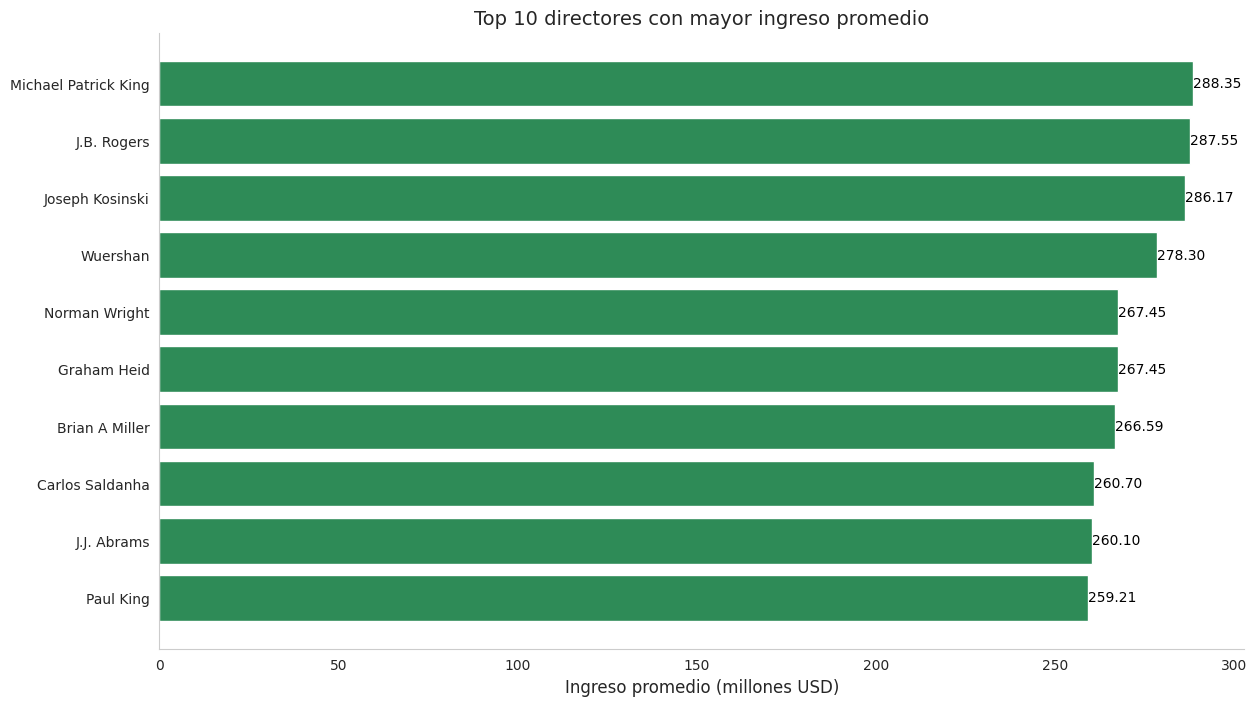

In [ ]:
fig, ax = plt.subplots(figsize=(14,8))

bars = ax.barh(
    top_directores['Director'],
    top_directores['Ingreso promedio'],
    color='seagreen'
)
ax.set_title('Top 10 directores con mayor ingreso promedio', fontsize=14)
ax.set_xlabel('Ingreso promedio (millones USD)', fontsize=12)
ax.set_ylabel('')
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

ax.bar_label(bars, fontsize=10, color='black', fmt='%.2f')
ax.invert_yaxis()

plt.grid(visible=False)

plt.show()

¿Un buen director impacta en el éxito económico?


Actores principales

In [ ]:
# Agrupar por actores prinsipales
actores = (
    normalizado_credits_limpio[normalizado_credits_limpio['cast_order'] <= 2][['id', 'cast_name']]
    .drop_duplicates()
)

In [ ]:
# merge credits actores con muvies reducido
movies_credits_actores = (
    movies_reduced.merge(
        actores,
        left_on = 'id',
        right_on = 'id',
        how = 'left'
    )
)
movies_credits_actores = movies_credits_actores.dropna()
movies_credits_actores.sample(3)

,id,original_title,release_date,revenue,profit,roi,cast_name
3855,10647,Pay It Forward,2000-10-12,55.71,15.71,39.27,Haley Joel Osment
9168,16353,Ong Bak 2,2008-12-04,8.94,0.44,5.14,Sarunyu Wongkrachang
4992,13909,She Wore a Yellow Ribbon,1949-10-22,5.40,3.80,237.50,John Agar



Top 10 actores más rentables

In [ ]:
# Agrupar por actor y calcular el promedio del profit y el conteo de películas
stats_actores = (
    movies_credits_actores.groupby('cast_name')['profit']
    .agg(promedio_profit='mean', total_peliculas='count')
    .reset_index()
)

# Aplicar el filtro de consistencia (mínimo 5 películas)
actores_consistentes = stats_actores[stats_actores['total_peliculas'] >= 5]

# Obtener el Top 10
top_10_rentables = (
    actores_consistentes.sort_values(by='promedio_profit', ascending=False)
    .head(10)
)

# Formatear columnas para la presentación
top_10_rentables.columns = ['Actor', 'Ganancia Promedio por Película', 'Total de Películas']
top_10_rentables

,Actor,Ganancia Promedio por Película,Total de Películas
2367,Jason Biggs,140.908333,6
4697,Rowan Atkinson,138.402000,5
5188,Talia Shire,136.474000,5
776,Burt Young,126.006667,6
4653,Roger Moore,124.935556,9
5316,Tobin Bell,118.100000,6
5332,Tom Cruise,112.192273,22
2604,Jodie Foster,98.479091,11
3760,Melissa McCarthy,97.495714,7
2229,Jack Nicholson,90.711667,12


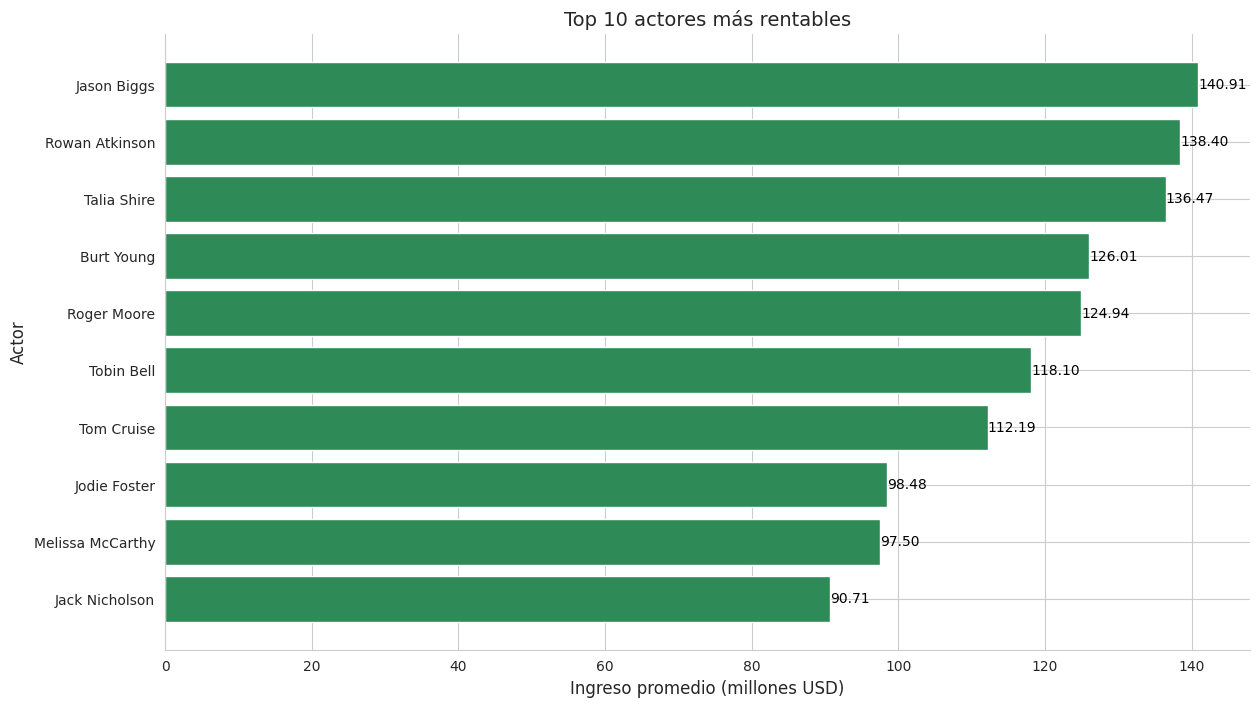

In [ ]:
fig, ax = plt.subplots(figsize=(14,8))

bars = ax.barh(
    top_10_rentables['Actor'],
    top_10_rentables['Ganancia Promedio por Película'],
    color='seagreen'
)

ax.set_title('Top 10 actores más rentables', fontsize=14)
ax.set_xlabel('Ingreso promedio (millones USD)', fontsize=12)
ax.set_ylabel('Actor', fontsize=12)

ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

ax.bar_label(bars, fontsize=10, color='black', fmt='%.2f')
ax.invert_yaxis()

plt.show()

#🧠 6. Keywords y tendencias

📌 Dataset: keywords.csv

Tareas:

- Identificar palabras clave más comunes

- Analizar keywords asociadas a películas exitosas

Responder:

- ¿Qué temáticas aparecen más en películas rentables?

- ¿Existen patrones por época (años)?

In [ ]:
df_keywords = pd.read_csv('/content/keywords.csv', on_bad_lines='skip')
keywords = df_keywords.copy()
keywords.sample(3)

,id,keywords
30446,3056,"[{'id': 1299, 'name': 'monster'}, {'id': 6737,..."
5223,24767,[]
10821,18747,"[{'id': 3149, 'name': 'gangster boss'}, {'id':..."


In [ ]:
# Normalizar la columna keywords (lista de diccionarios)
normalizado_keywords = normalizar_lista_diccionarios(keywords, 'keywords', 'kw')
normalizado_keywords.sample(3)


,id,kw_id,kw_name
109093,166271,6155.0,afterlife
31294,23949,41596.0,denial
7431,11216,5091.0,kiss


Tratar nulos

In [ ]:
normalizado_keywords.duplicated().sum()

np.int64(2533)

In [ ]:
normalizado_keywords = normalizado_keywords.drop_duplicates()

In [ ]:
# Se identificaron 14,795 valores nulos en el conjunto de datos.
# La columna kw_id se completará con el valor 0.
# La columna kw_name se completará con el texto "NoKeyword".
normalizado_keywords['kw_id'] = normalizado_keywords['kw_id'].fillna(0).astype(int)
normalizado_keywords['kw_name'] = normalizado_keywords['kw_name'].fillna('NoKeyword')

In [ ]:
# Guardar dataset normalizado
normalizado_keywords.to_csv('keywords_normalizado.csv', index=False)

In [ ]:
# Unir normalizado_keywords con movies_reducted
keywords_movies = (
    normalizado_keywords.merge(
        movies_reduced,
        left_on = 'id',
        right_on = 'id',
        how = 'left'
    )
)
keywords_movies.sample(3)

,id,kw_id,kw_name,original_title,release_date,revenue,profit,roi
68639,29617,8653,niagara falls,NaN,NaT,NaN,NaN,NaN
137950,26189,1735,amateur detective,NaN,NaT,NaN,NaN,NaN
45083,11864,5385,survivor,Enemy Mine,1985-12-12,12.3,-27.7,-69.24


In [ ]:
# Eliminar nulos el dataset keywords_movies
keywords_movies = keywords_movies.dropna(
    subset=["revenue", "profit", "original_title"]
)

In [ ]:
# Guardar dataset merge keywords y movies
keywords_movies.to_csv('keywords_movies.csv', index=False)

- ¿Qué temáticas aparecen más en películas rentables?


In [ ]:
# Agrupar por keyword y calcular metricas
keywords_metrics = (
    keywords_movies.groupby('kw_name')
    .agg(
        avg_revenue = ('revenue', 'mean'),
        total_revenue = ('revenue', 'sum'),
        avg_profit = ('profit', 'mean'),
        avg_roi = ('roi', 'mean'),
        count_movies = ('original_title', 'count')
    )
    .sort_values(by='avg_roi', ascending=False)
)

# Top 20 keywords con mayor rio promedio
top_keywords = keywords_metrics.head(20).reset_index()
# Redondear a .2 decimales
top_keywords = top_keywords.round(2)
top_keywords

,kw_name,avg_revenue,total_revenue,avg_profit,avg_roi,count_movies
0,entity,193.36,193.36,193.34,1288938.67,1
1,film,248.00,248.00,247.94,413233.33,1
2,footage,248.00,248.00,247.94,413233.33,1
3,korean movie,11.08,11.08,11.08,221568.98,1
4,demonic possession,104.23,938.06,91.67,146521.31,9
5,psychic,51.11,459.96,33.27,143290.52,9
6,sorcery,106.48,319.45,76.46,137753.57,3
7,haunting,87.08,870.81,65.47,130135.01,10
8,maryland,151.18,604.74,116.07,103674.42,4
9,lost,99.40,397.61,89.01,103456.36,4



- ¿Existen patrones por época (años)?

In [ ]:
keywords_movies['release_date'] = pd.to_datetime(
    keywords_movies['release_date'], errors='coerce')
# 1. Crear la columna de año
keywords_movies['year'] = keywords_movies['release_date'].dt.year
# 2. Crear la columna de década
keywords_movies['decade'] = (keywords_movies['year'] // 10) * 10

In [ ]:
patrones_reales = (
    keywords_movies.groupby(['decade', 'kw_name'])
    .agg(
        cantidad_peliculas=('id', 'count'),
        recaudacion_total=('revenue', 'sum'),
        recaudacion_promedio=('revenue', 'mean')
    ).reset_index()
)
patrones_reales

,decade,kw_name,cantidad_peliculas,recaudacion_total,recaudacion_promedio
0,1910,NoKeyword,1,0.14,0.14
1,1910,army,1,11.00,11.00
2,1910,ku klux klan,1,11.00,11.00
3,1910,new york,1,8.00,8.00
4,1910,orphan,1,8.00,8.00
...,...,...,...,...,...
18772,2010,zookeeper,2,200.52,100.26
18773,2010,Γη,1,74.60,74.60
18774,2010,битва,1,56.00,56.00
18775,2010,воин,1,56.00,56.00


In [ ]:
patrones_reales = patrones_reales[patrones_reales['cantidad_peliculas'] >= 5]

top_por_epoca = (
    patrones_reales.sort_values(by=['decade', 'recaudacion_total'], ascending=[True, False])
    .groupby('decade').head(5)
)
top_por_epoca

,decade,kw_name,cantidad_peliculas,recaudacion_total,recaudacion_promedio
99,1920,silent film,8,35.50,4.437500
499,1940,film noir,8,65.06,8.132500
675,1940,suspense,7,50.16,7.165714
1063,1950,musical,9,405.43,45.047778
872,1950,epic,5,353.80,70.760000
979,1950,jealousy,6,69.38,11.563333
1083,1950,nurse,5,63.81,12.762000
899,1950,film noir,6,52.05,8.675000
1866,1960,musical,9,863.67,95.963333
2055,1960,secret organization,6,598.13,99.688333


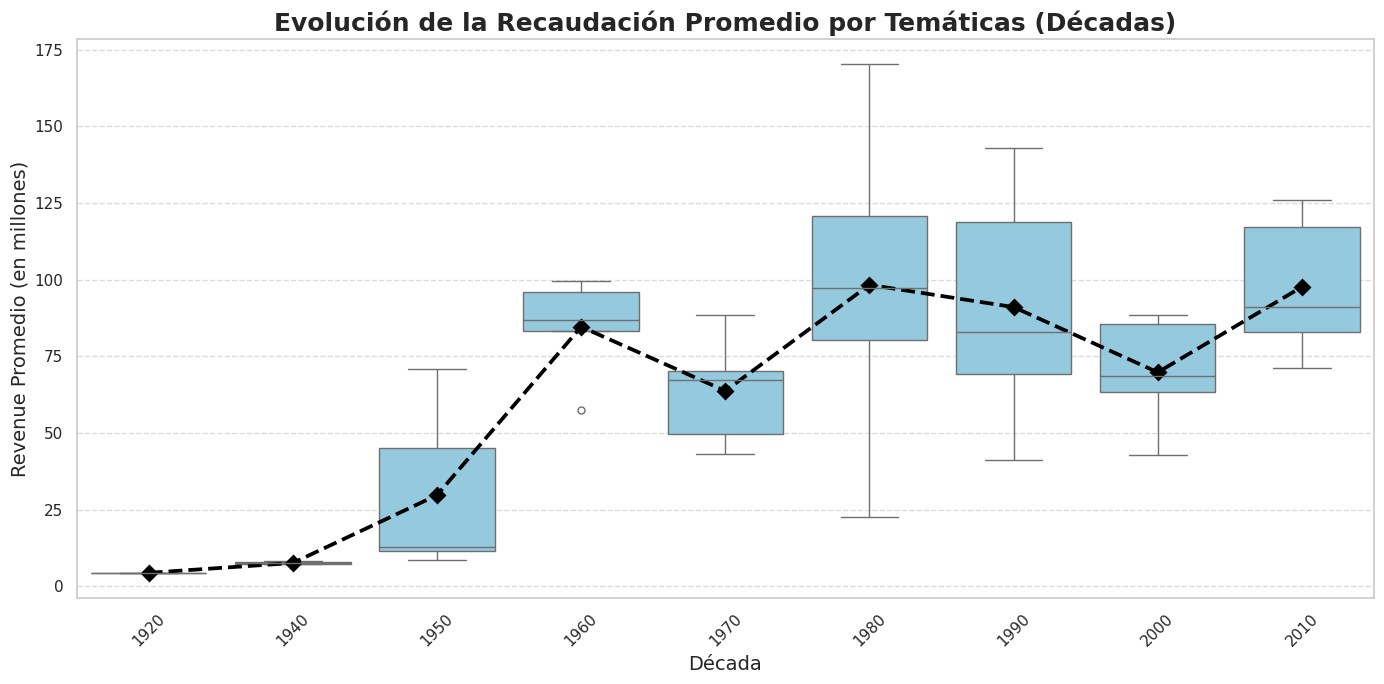

In [ ]:
# 1. Configuración de estilo
sns.set_theme(style="whitegrid")
plt.figure(figsize=(14, 7))

# 2. Crear el Boxplot
sns.boxplot(
    data=top_por_epoca,
    x="decade",
    y="recaudacion_promedio",
    color="skyblue",
    fliersize=5
)

# 3. Crear el Pointplot (la línea de tendencia)
sns.pointplot(
    data=top_por_epoca,
    x="decade",
    y="recaudacion_promedio",
    color="black",
    markers="D",
    linestyles="--",
    estimator="mean",
    errorbar=None
)

# 4. Personalización de etiquetas y títulos
plt.title("Evolución de la Recaudación Promedio por Temáticas (Décadas)", fontsize=18, weight="bold")
plt.xlabel("Década", fontsize=14)
plt.ylabel("Revenue Promedio (en millones)", fontsize=14)

# 5. Ajustes finales de los ejes
plt.xticks(rotation=45)
plt.grid(axis='y', linestyle='--', alpha=0.7)

plt.tight_layout()
plt.show()

 Tras limpiar el ruido de los datos, corregir las distorsiones de las variables duplicadas y segmentar el rendimiento histórico, se consolidan tres grandes pilares estratégicos:

1. El Mito del "Éxito Crítico" vs. La Realidad Comercial
Los datos demuestran de forma contundente que la alta calificación de una película (rating) no garantiza su éxito financiero. El análisis de dispersión reveló que el grueso de la recaudación masiva (blockbusters) se concentra en producciones con calificaciones intermedias (entre 3 y 4 estrellas).

Insight: La taquilla está gobernada por la accesibilidad comercial, las campañas de marketing y los canales de distribución, más que por el valor artístico percibido. Para un estudio, buscar la "perfección crítica" no es una métrica de rendimiento financiero confiable.

2. Gestión de Portafolio: "Zonas Seguras" vs. Apuestas de Alto Riesgo
El comportamiento del Retorno de Inversión (ROI) y el volumen de producción por género dictan cómo se debe diversificar el capital de un estudio:

Los Motores de Rentabilidad: Géneros como Animación, Familia y Fantasía presentan los ratios de ROI más saludables y estables. Aunque requieren presupuestos iniciales altos, su capacidad de explotación comercial y su audiencia global cautiva los convierten en inversiones prioritarias.

Las Zonas Seguras de Contención: Drama y Comedia se consolidan como los pilares de volumen de la industria. Mantienen costos de producción moderados y un ROI predecible, lo que permite a los estudios mantener un flujo de caja constante y absorber las pérdidas de proyectos más arriesgados.

3. La Popularidad como Métrica de Tráfico, No de Calidad
Se observó una correlación estadística casi nula entre el volumen de interacciones/votos (popularidad) y la nota media de las películas. Las películas altamente populares reflejan tendencias culturales, fenómenos mediáticos o el impacto del fandom, pero el comportamiento del espectador promedio a nivel de satisfacción sigue una distribución normal y moderada.

Recomendación Estratégica de Cierre (El "Takeaway" de Negocio)
Para maximizar las probabilidades de éxito en la industria actual, un estudio no debe apostar a un único "éxito de taquilla" aislado. La estrategia óptima consiste en construir un portafolio diversificado: financiar producciones de Drama o Comedia de bajo costo para asegurar la base operativa, e inyectar el capital fuerte en proyectos de Animación o Aventura altamente comerciales, sabiendo que el marketing masivo y la fecha de estreno dictarán el retorno financiero con mayor fuerza que la misma crítica cinematográfica.